**CURSO**: Análisis Geoespacial, Departamento de Geociencias y Medio Ambiente, Universidad Nacional de Colombia - sede Medellín <br/>
**Profesor**: Edier Aristizábal (evaristizabalg@unal.edu.co) <br />
**Credits**: The content of this notebook is taken from several sources, mainly from [OWSLib](https://owslib.readthedocs.io/), [NASA GIBS](https://nasa-gibs.github.io/gibs-api-docs/), [Smithsonian Global Volcanism Program](https://volcano.si.edu/), [USGS Earthquake Hazards Program](https://earthquake.usgs.gov/fdsnws/event/1/), [OSMnx](https://osmnx.readthedocs.io/), [pystac-client](https://pystac-client.readthedocs.io/), [Copernicus Data Space Ecosystem](https://documentation.dataspace.copernicus.eu/), [Introduction to web mapping](https://web-mapping.surge.sh/index.html) by Michael Dorman, and the courses and book open and freely published by [Dani Arribas-Bel](http://darribas.org/) & Sergio Rey. Every effort has been made to trace copyright holders of the materials used in this book. The author apologies for any unintentional omissions and would be pleased to add an acknowledgment in future editions.

# Geoservicios, APIs y mapas interactivos

Este notebook reúne las principales formas de **obtener información geográfica directamente desde internet**, sin descargar archivos manualmente, y de **visualizarla en mapas interactivos**:

1. **Geoservicios OGC**: WMS (IGAC y NASA), WMTS (NASA) y WFS (Smithsonian e IGAC).
2. **APIs REST**: catálogo de sismos del USGS.
3. **OpenStreetMap** con `osmnx`: límites, red vial y equipamientos de Medellín.
4. **Imágenes de satélite**: catálogos STAC (`sat-search` → `pystac-client`) y Copernicus (`sentinelsat` → API OData del Copernicus Data Space).
5. **Geocodificación** con Nominatim (`geopy`).
6. **Mapas interactivos**: contextily, folium, Bokeh (`WMTSTileSource`), gmplot, plotly, Basemap y Leaflet.

> **Nota**: todos los ejemplos dependen de servidores externos. Si una celda falla, verifique primero que el servicio esté en línea (los servidores institucionales cambian de URL o se caen con frecuencia). Los ejemplos fueron verificados en octubre de 2026.

## Librerías

In [ ]:
# Instalar lo que haga falta (una sola vez)
# !pip install owslib geopandas rasterio contextily folium osmnx pystac-client geopy plotly bokeh gmplot basemap

In [23]:
import io
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import requests

pd.set_option('display.max_columns', None)

# Área de estudio: Valle de Aburrá (lon_min, lat_min, lon_max, lat_max)
bbox_aburra = (-75.75, 6.00, -75.30, 6.45)
# Colombia continental
bbox_colombia = (-80.0, -5.0, -66.0, 13.0)

## 1. Geoservicios OGC

Los geoservicios permiten el intercambio y acceso a la información geográfica publicada por los organismos o entidades productoras de información georreferenciada. Para su publicación se utilizan los lenguajes y protocolos estándar definidos por el **Open Geospatial Consortium (OGC)**, que busca estándares abiertos e interoperables entre los Sistemas de Información Geográfica (SIG) y la World Wide Web (WWW).

| Estándar | Qué entrega | Uso típico |
|---|---|---|
| **WMS** (Web Map Service) | Una **imagen** (PNG/JPG) del mapa ya renderizado para un bbox y un tamaño dados | Visualizar capas como fondo o contexto |
| **WMTS** (Web Map Tile Service) | **Teselas** (tiles) pre-renderizadas en una pirámide de zoom | Mapas web rápidos (lo que usan Google Maps, OSM, ESRI) |
| **WFS** (Web Feature Service) | Los **datos vectoriales** (geometría + atributos), en GML, GeoJSON, etc. | Descargar y analizar entidades |
| **WCS** (Web Coverage Service) | Los **datos raster** (valores, no colores) | Descargar DEM, clima, etc. |

Todos funcionan con peticiones HTTP. Las más importantes son:

- `GetCapabilities`: describe el servicio (capas, sistemas de referencia, formatos, extensión).
- `GetMap` (WMS) / `GetTile` (WMTS) / `GetFeature` (WFS) / `GetCoverage` (WCS): obtienen el producto.

En Python, la librería [OWSLib](https://owslib.readthedocs.io/) construye estas peticiones por nosotros.

In [26]:
from owslib.wms import WebMapService
from owslib.wmts import WebMapTileService
from owslib.wfs import WebFeatureService

### 1.1 WMS del IGAC

El Instituto Geográfico Agustín Codazzi publica sus servicios en un ArcGIS Server. Su directorio está en [https://mapas.igac.gov.co/server/rest/services](https://mapas.igac.gov.co/server/rest/services) (ábralo en el navegador: es la misma información que vamos a consultar desde Python).

El directorio está organizado así:

```
https://mapas.igac.gov.co/server/rest/services          ← directorio raíz: lista de carpetas
    └── relieve                                         ← carpeta temática: lista de servicios
          └── srtm30metros/MapServer                    ← servicio: descripción, capas, extensiones (WMS, WFS...)
```

El servicio que se usaba antes en el curso (`carto/carto100000colombia2019`) ya no responde, por eso conviene saber **buscar** en el directorio. Vamos a recorrerlo paso a paso para encontrar un **modelo digital de elevación** y un **mapa de pendientes** del IGAC.

La API REST de ArcGIS devuelve JSON si se agrega el parámetro `f=json`. Empezamos por el directorio raíz:

In [45]:
igac_rest = 'https://mapas.igac.gov.co/server/rest/services'

# 1. Hacer la petición GET: URL base + parámetro f=json (pedir la respuesta en JSON)
respuesta = requests.get(igac_rest, params={'f': 'json'}, timeout=60)

# 2. Revisar la respuesta: código de estado (200 = OK) y la URL completa que se armó
print('Código de estado:', respuesta.status_code)
print('URL:', respuesta.url)

# 3. Convertir el cuerpo de la respuesta (texto JSON) en un diccionario de Python
contenido = respuesta.json()
print('Claves del diccionario:', list(contenido.keys()))

Código de estado: 200
URL: https://mapas.igac.gov.co/server/rest/services?f=json
Claves del diccionario: ['currentVersion', 'folders', 'services']


In [91]:
# 4. Extraer la lista de carpetas del servidor
carpetas = contenido['folders']
print(carpetas)

['agrologia', 'ambiente', 'asuntosinternacionales', 'atlas', 'carto', 'cartografia_tableros', 'catastro', 'centrocontrol', 'geodesia', 'Hosted', 'ICDE', 'imagenes', 'indigenas', 'infraestructura', 'limites', 'minasyenergia', 'nombresgeograficos', 'ObservatorioInmobiliario', 'ordenamientoterritorial', 'otros', 'poblacion', 'regulacion', 'relieve', 'seguridad', 'test', 'Utilities']


Las carpetas son temáticas. Como buscamos un modelo de elevación, la carpeta lógica es **`relieve`**. Consultamos su contenido con la misma petición, agregando el nombre de la carpeta a la URL:

In [46]:
# 2. Hacer la petición pidiendo la respuesta en JSON
respuesta = requests.get('https://mapas.igac.gov.co/server/rest/services/relieve', params={'f': 'json'}, timeout=60)
print('Código de estado:', respuesta.status_code)

# 3. Convertir la respuesta en diccionario
contenido = respuesta.json()

# 4. Extraer la lista de servicios: cada uno es un diccionario con su nombre y su tipo
servicios = contenido['services']
servicios

Código de estado: 200


[{'name': 'relieve/srtm30metros', 'type': 'MapServer'}]

In [47]:
# 2. Pedir la ficha en JSON
respuesta = requests.get('https://mapas.igac.gov.co/server/rest/services/relieve/srtm30metros/MapServer', params={'f': 'json'}, timeout=60)
respuesta.json()  # Convertir la respuesta en diccionario

{'currentVersion': 11.3,
 'cimVersion': '3.3.0',
 'serviceDescription': '<DIV STYLE="text-align:Left;font-size:12pt"><P><SPAN>La Shuttle Radar Topography Mission (SRTM), es la misión de la Administración Nacional de Aeronáutica (NASA) y otros organismos como la Agencia Nacional de Inteligencia Geoespacial (NGA) destinada al desarrollo de Modelos Digitales de Elevación o DEM. Esta mision voló a bordo del transbordador espacial Endeavour del 11 al 22 de febrero de 1994.</SPAN></P></DIV>',
 'mapName': 'SRTM 30 metros',
 'description': '<DIV STYLE="text-align:Left;font-size:12pt"><P><SPAN>La Shuttle Radar Topography Mission (SRTM), es la misión de la Administración Nacional de Aeronáutica (NASA) y otros organismos como la Agencia Nacional de Inteligencia Geoespacial (NGA) destinada al desarrollo de Modelos Digitales de Elevación o DEM. Esta mision voló a bordo del transbordador espacial Endeavour del 11 al 22 de febrero de 1994.</SPAN></P></DIV>',
 'copyrightText': 'Instituto Geográfico Ag

La ficha confirma que `relieve/srtm30metros` es el **SRTM de 30 m**, que tiene una sola capa (id `0`) y que tiene habilitada la extensión **`WMSServer`**. Pero no dice **en qué URL** está ese WMS.

Para saberlo, abra la ficha en el navegador (sin `?f=json`):
[https://mapas.igac.gov.co/server/rest/services/relieve/srtm30metros/MapServer](https://mapas.igac.gov.co/server/rest/services/relieve/srtm30metros/MapServer).
Junto a *Supported Extensions* aparece un enlace **WMS**: es el propio servidor el que indica dónde está su WMS. Lo mismo se puede hacer desde Python: pedimos la ficha en HTML y buscamos los enlaces que contengan `WMSServer`:

El enlace está en **`/server/services/...`**, no en `/server/rest/services/...`. ArcGIS Server (el software que usa el IGAC) tiene dos "puertas" en el mismo servidor:

| Ruta | Qué es | Para qué sirve |
|---|---|---|
| `/server/rest/services/...` | API REST de Esri (*Services Directory*) | Explorar: carpetas, fichas, capas. Responde HTML o JSON (`f=json`) |
| `/server/services/.../MapServer/WMSServer` | Servicio **OGC estándar** (también `/WFSServer`, `/WCSServer`) | Lo que entienden OWSLib, QGIS, folium, Leaflet |

Comprobémoslo: hacemos la misma petición `GetCapabilities` por las dos rutas y miramos qué tipo de contenido devuelve cada una:

In [48]:
# parámetros de una petición WMS GetCapabilities
params_wms = {'service': 'WMS', 'request': 'GetCapabilities'}

# 1. Por la puerta REST: el servidor ignora los parámetros WMS y devuelve la página HTML de la ficha
r1 = requests.get('https://mapas.igac.gov.co/server/rest/services/service/MapServer/WMSServer', params=params_wms, timeout=60)
print(r1.text[:300])


<html lang="en">
<head>
<title>
Error: Invalid URL</title>
<link href="/server/rest/static/main.css" rel="stylesheet" type="text/css"/>
</head>
<body>
<table width="100%" class="userTable">
<tr>
<td class="titlecell">ArcGIS REST Framework</td>
</tr>
</table>
<table width="100%" class="na


In [49]:
# 2. Por la puerta OGC: devuelve el XML con las capacidades del WMS
r2 = requests.get('https://mapas.igac.gov.co/server/services/relieve/srtm30metros/MapServer/WMSServer', params=params_wms, timeout=60)
print(r2.text[:300])

<?xml version="1.0" encoding="UTF-8"?>
<WMS_Capabilities version="1.3.0"
  xmlns="http://www.opengis.net/wms"
  xmlns:xsi="http://www.w3.org/2001/XMLSchema-instance"
  xmlns:esri_wms="http://www.esri.com/wms"
  xsi:schemaLocation="http://www.opengis.net/wms http://schemas.opengis.net/wms/1.3.0/capab


Solo la segunda ruta responde como un WMS (`text/xml` con `<WMS_Capabilities>`). La regla general para **cualquier ArcGIS Server** (IGAC, SGC, alcaldías...) es:

```
https://mapas.igac.gov.co/server  +  /services/  +  relieve/srtm30metros  +  /MapServer/WMSServer
         servidor                                    nombre del servicio        extensión WMS
```

> En otros programas la convención cambia. En **GeoServer** (el que usa el Smithsonian más adelante) las rutas son `/geoserver/wms` y `/geoserver/wfs`. Por eso lo más seguro siempre es buscar el enlace en la página del servicio.

In [50]:
# 3. Conectarse al servicio: OWSLib hace la petición GetCapabilities
igac = WebMapService('https://mapas.igac.gov.co/server/services/relieve/srtm30metros/MapServer/WMSServer', version='1.1.1', timeout=120)

# 4. Revisar la identificación del servicio
print(igac.identification.type)

OGC:WMS


Listar las capas publicadas en el servicio WMS y sus propiedades

In [115]:
list(igac.contents)

['0']

In [116]:
capa = igac['0']
print('Título:     ', capa.title)
print('Consultable:', capa.queryable)
print('Opaca:      ', capa.opaque)
print('BBox WGS84: ', capa.boundingBoxWGS84)
print('CRS:        ', capa.crsOptions)
print('Estilos:    ', capa.styles)

Título:      SRTM_30.tif
Consultable: 1
Opaca:       0
BBox WGS84:  (-79.622296, -4.711642, -65.922663, 13.021344)
CRS:         ['EPSG:4326']
Estilos:     {'default': {'title': 'SRTM_30.tif', 'legend': 'https://mapas.igac.gov.co:443/server/services/relieve/srtm30metros/MapServer/WMSServer?request=GetLegendGraphic%26version=1.1.1%26format=image/png%26layer=0'}}


In [117]:
# 1. Operaciones que soporta el servicio
operaciones = []
for op in igac.operations:
    operaciones.append(op.name)
print(operaciones)

# 2. Formatos de imagen que entrega la operación GetMap
op_getmap = igac.getOperationByName('GetMap')
print(op_getmap.formatOptions)

['GetCapabilities', 'GetMap', 'GetFeatureInfo', 'GetStyles']
['image/bmp', 'image/jpeg', 'image/tiff', 'image/png', 'image/png8', 'image/png24', 'image/png32', 'image/gif', 'image/svg+xml']


Obtener la imagen (`GetMap`) para el Valle de Aburrá

In [51]:
# 1. Pedir la imagen al servidor (petición GetMap)
img = igac.getmap(layers=['0'],
                  styles=[''],
                  srs='EPSG:4326',
                  bbox=bbox_aburra,
                  size=(800, 800),
                  format='image/png',
                  transparent=True)

# 2. Leer los bytes de la respuesta
contenido_img = img.read()

# 3. Guardar los bytes en un archivo PNG
with open('srtm_aburra_wms.png', 'wb') as f:
    f.write(contenido_img)

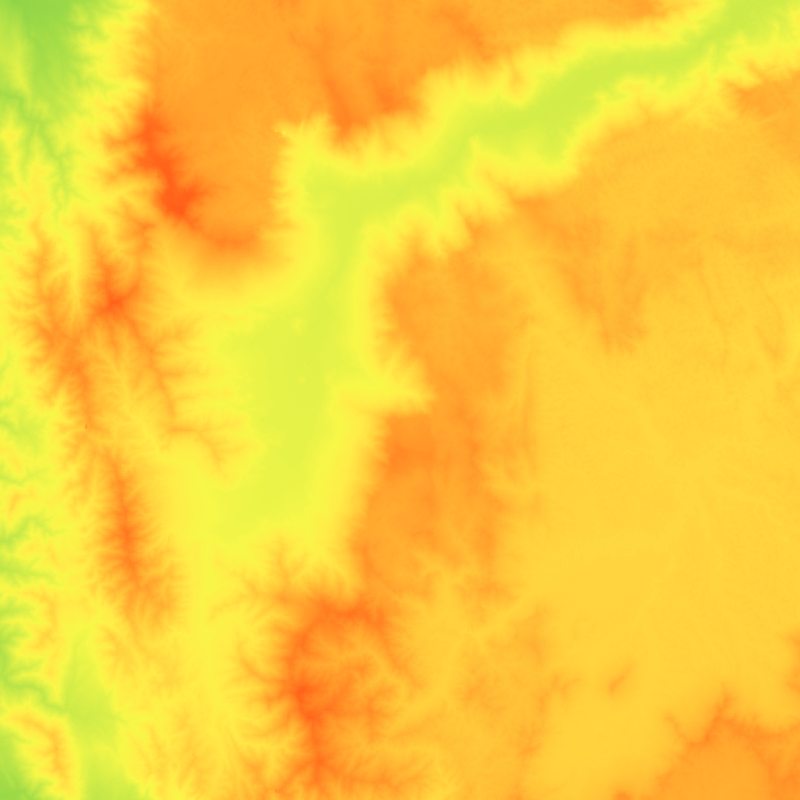

In [52]:
from IPython.display import Image

Image('srtm_aburra_wms.png', width=400)

La imagen **no tiene coordenadas**: es solo un PNG. Como nosotros definimos el `bbox`, podemos ubicarla en el espacio con `extent` en matplotlib, o incluso georreferenciarla como GeoTIFF. Pero hay que recordar que un WMS entrega **colores, no valores de elevación**: sirve para visualizar, no para calcular pendientes ni hacer álgebra de mapas (para eso está el WCS o la descarga del raster original).

### 1.3 WMTS de la NASA

En un **WMTS** el servidor no dibuja la imagen a pedido: tiene una **pirámide de teselas** ya calculadas (`TileMatrixSet`), y el cliente pide la tesela de la fila y columna que necesita para cada nivel de zoom. Es mucho más rápido y es lo que usan todos los mapas web.

In [123]:
# 1. Conectarse al WMTS (se lee el documento de capacidades)
url_wmts = 'https://gibs.earthdata.nasa.gov/wmts/epsg4326/best/1.0.0/WMTSCapabilities.xml'
wmts = WebMapTileService(url_wmts)

# 2. Revisar el servicio
print(wmts.identification.title)
wmts.contents

NASA Global Imagery Browse Services for EOSDIS


{'MERRA2_2m_Air_Temperature_Monthly': <owslib.wmts.ContentMetadata at 0x17d4024fcb0>,
 'MERRA2_2m_Air_Temperature_Assimilated_Monthly': <owslib.wmts.ContentMetadata at 0x17d41b43d90>,
 'GEDI_ISS_L4B_Aboveground_Biomass_Density_Mean_201904-202303': <owslib.wmts.ContentMetadata at 0x17d41b43e70>,
 'GEDI_ISS_L4B_Aboveground_Biomass_Density_PercentStandardError_201904-202303': <owslib.wmts.ContentMetadata at 0x17d402a4210>,
 'GEDI_ISS_L4B_Aboveground_Biomass_Density_StandardError_201904-202303': <owslib.wmts.ContentMetadata at 0x17d402a4590>,
 'AVISO_Absolute_Dynamic_Topography': <owslib.wmts.ContentMetadata at 0x17d402a4ad0>,
 'SWDB_Aerosol_Angstrom_Exponent_Daily': <owslib.wmts.ContentMetadata at 0x17d402a4bb0>,
 'SWDB_Aerosol_Angstrom_Exponent_Monthly': <owslib.wmts.ContentMetadata at 0x17d402a4c90>,
 'OMPS_NOAA21_LimbProfiler_Aerosol_ExtinctionCoefficient_12KM': <owslib.wmts.ContentMetadata at 0x17d402a4d70>,
 'OMPS_SNPP_LimbProfiler_Aerosol_ExtinctionCoefficient_12KM': <owslib.wmts.Co

In [124]:
# 3. Pirámides de teselas disponibles (TileMatrixSet)
print(list(wmts.tilematrixsets))

['16km', '2km', '1km', '500m', '250m', '31.25m', '15.625m']


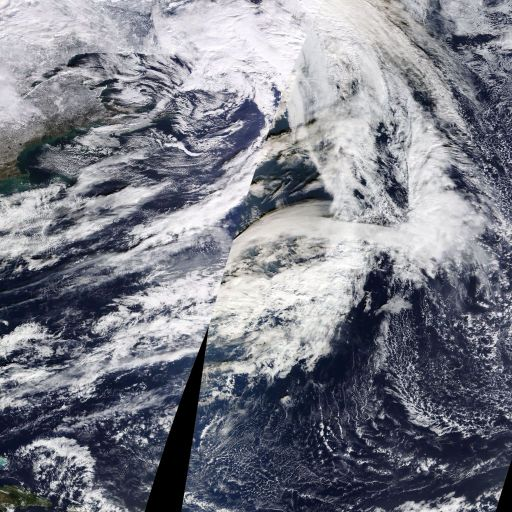

In [125]:
# 1. Pedir una tesela: nivel de zoom (tilematrix), fila y columna
tile = wmts.gettile(layer='MODIS_Terra_CorrectedReflectance_TrueColor',
                    tilematrixset='250m',
                    tilematrix='3',
                    row=1,
                    column=3,
                    format='image/jpeg',
                    time='2024-01-15')

# 2. Leer los bytes y mostrarlos
bytes_tile = tile.read()
Image(bytes_tile, width=400)

Los WMTS en proyección Web Mercator (`EPSG:3857`) suelen exponerse también como una **plantilla XYZ** `{z}/{y}/{x}`, que es lo que entienden directamente contextily, folium, plotly y Leaflet. La usaremos más adelante:

In [25]:
# plantilla XYZ: {z} = zoom, {y} = fila, {x} = columna
gibs_xyz = ('https://gibs.earthdata.nasa.gov/wmts/epsg3857/best/MODIS_Terra_CorrectedReflectance_TrueColor/'
            'default/2024-01-15/GoogleMapsCompatible_Level9/{z}/{y}/{x}.jpg')
print(gibs_xyz)

https://gibs.earthdata.nasa.gov/wmts/epsg3857/best/MODIS_Terra_CorrectedReflectance_TrueColor/default/2024-01-15/GoogleMapsCompatible_Level9/{z}/{y}/{x}.jpg


#### ¿Cómo se numeran las teselas?

En una pirámide XYZ, en el nivel de zoom `z` el mundo se divide en `2^z × 2^z` teselas de 256 × 256 píxeles:

- `z`: nivel de zoom. En `z = 0` hay una sola tesela con el mundo entero; en `z = 9` hay 512 × 512.
- `x`: columna, contada desde la izquierda (longitud −180°).
- `y`: fila, contada desde **arriba** (latitud ≈ 85° N).

<center><img src="https://miro.medium.com/max/2400/1*OvBZQR8cwZCd9rghXfGpfg.png" width="900"></center>

La siguiente celda descarga las 16 teselas del zoom 2 y las rotula con su `x, y`:


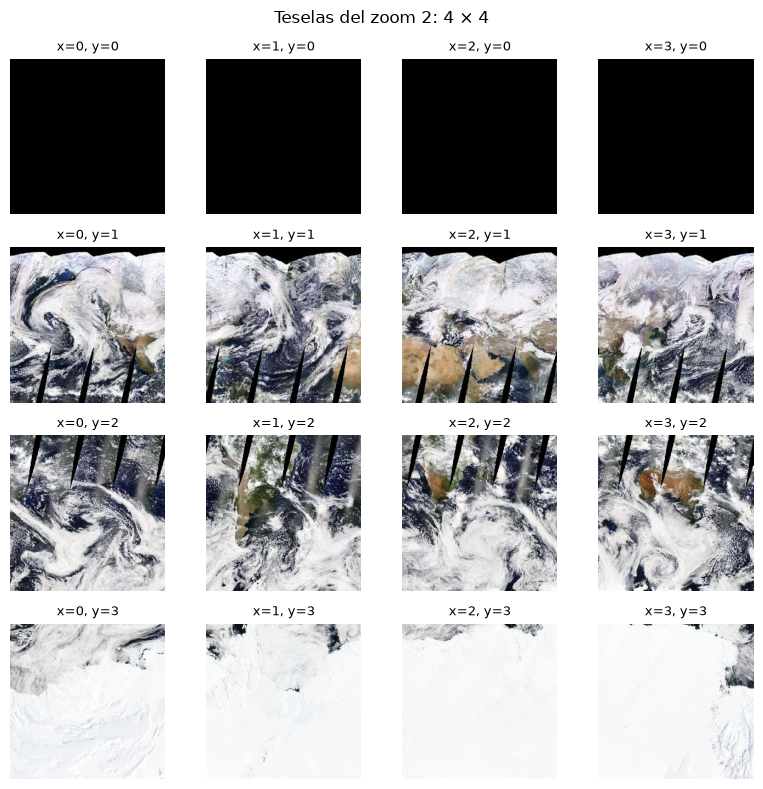

In [65]:
z = 2
n = 2 ** z      # 4 teselas por lado

fig, ax = plt.subplots(n, n, figsize=(8, 8))

for y in range(n):          # filas, de arriba hacia abajo
    for x in range(n):      # columnas, de izquierda a derecha
        # 1. URL de la tesela
        url = gibs_xyz.format(z=z, y=y, x=x)
        # 2. Descargarla y leerla como imagen
        r = requests.get(url, timeout=60)
        img_tesela = plt.imread(io.BytesIO(r.content), format='jpeg')
        # 3. Dibujarla en su posición y rotularla
        ax[y, x].imshow(img_tesela)
        ax[y, x].set_title(f'x={x}, y={y}', fontsize=9)
        ax[y, x].set_axis_off()

fig.suptitle(f'Teselas del zoom {z}: {n} × {n}')
plt.tight_layout()

La fila `y = 0` (el Ártico) sale negra: en enero allí es noche polar y MODIS, un sensor óptico, no registra nada sin luz solar. Las cuñas negras son los huecos entre las órbitas del satélite en ese día.

Para calcular la tesela que contiene cualquier punto se usan las fórmulas de la proyección Web Mercator:

$$x = \left\lfloor \frac{lon + 180}{360} \cdot 2^z \right\rfloor \qquad
y = \left\lfloor \frac{1 - \dfrac{\operatorname{asinh}(\tan(lat))}{\pi}}{2} \cdot 2^z \right\rfloor$$

In [61]:
import math


def tesela(lon, lat, z):
    # 1. Número de teselas por lado en este nivel de zoom
    n = 2 ** z

    # 2. Columna: proporción de la longitud entre -180 y 180
    x = int((lon + 180) / 360 * n)

    # 3. Fila: proyección Mercator de la latitud, contada desde arriba
    lat_rad = math.radians(lat)
    y_merc = math.asinh(math.tan(lat_rad))
    y = int((1 - y_merc / math.pi) / 2 * n)

    return x, y


# Medellín en varios niveles de zoom
for z in [0, 3, 5, 7, 9]:
    x, y = tesela(-75.58, 6.25, z)
    print(f'z={z}  x={x}  y={y}')

z=0  x=0  y=0
z=3  x=2  y=3
z=5  x=9  y=15
z=7  x=37  y=61
z=9  x=148  y=247


Reemplazando `{z}`, `{y}` y `{x}` en la plantilla se obtiene la URL de una tesela, que se puede abrir directamente en el navegador. Estas son las teselas que contienen a **Medellín** en distintos niveles de zoom (MODIS, 15 de enero de 2024):

| Zoom `z` | Columna `x` | Fila `y` | Tesela |
|---|---|---|---|
| 0 | 0 | 0 | [https://gibs.earthdata.nasa.gov/wmts/epsg3857/best/MODIS_Terra_CorrectedReflectance_TrueColor/default/2024-01-15/GoogleMapsCompatible_Level9/0/0/0.jpg](https://gibs.earthdata.nasa.gov/wmts/epsg3857/best/MODIS_Terra_CorrectedReflectance_TrueColor/default/2024-01-15/GoogleMapsCompatible_Level9/0/0/0.jpg) |
| 3 | 2 | 3 | [https://gibs.earthdata.nasa.gov/wmts/epsg3857/best/MODIS_Terra_CorrectedReflectance_TrueColor/default/2024-01-15/GoogleMapsCompatible_Level9/3/3/2.jpg](https://gibs.earthdata.nasa.gov/wmts/epsg3857/best/MODIS_Terra_CorrectedReflectance_TrueColor/default/2024-01-15/GoogleMapsCompatible_Level9/3/3/2.jpg) |
| 5 | 9 | 15 | [https://gibs.earthdata.nasa.gov/wmts/epsg3857/best/MODIS_Terra_CorrectedReflectance_TrueColor/default/2024-01-15/GoogleMapsCompatible_Level9/5/15/9.jpg](https://gibs.earthdata.nasa.gov/wmts/epsg3857/best/MODIS_Terra_CorrectedReflectance_TrueColor/default/2024-01-15/GoogleMapsCompatible_Level9/5/15/9.jpg) |
| 7 | 37 | 61 | [https://gibs.earthdata.nasa.gov/wmts/epsg3857/best/MODIS_Terra_CorrectedReflectance_TrueColor/default/2024-01-15/GoogleMapsCompatible_Level9/7/61/37.jpg](https://gibs.earthdata.nasa.gov/wmts/epsg3857/best/MODIS_Terra_CorrectedReflectance_TrueColor/default/2024-01-15/GoogleMapsCompatible_Level9/7/61/37.jpg) |
| 9 | 148 | 247 | [https://gibs.earthdata.nasa.gov/wmts/epsg3857/best/MODIS_Terra_CorrectedReflectance_TrueColor/default/2024-01-15/GoogleMapsCompatible_Level9/9/247/148.jpg](https://gibs.earthdata.nasa.gov/wmts/epsg3857/best/MODIS_Terra_CorrectedReflectance_TrueColor/default/2024-01-15/GoogleMapsCompatible_Level9/9/247/148.jpg) |

> **Ojo con el orden**: en GIBS la URL es `{z}/{y}/{x}` (fila antes que columna). En otros servidores, como OpenStreetMap, es `{z}/{x}/{y}`.
>
> Esta capa llega solo hasta el **zoom 9** (`GoogleMapsCompatible_Level9`, ≈ 250 m por píxel). Si se pide el zoom 10, el servidor responde con error 400. Cambiando la fecha (`2024-01-15`) en la URL se obtiene la imagen de otro día.

In [66]:
# 1. Calcular la tesela de un punto
z = 7
x, y = tesela(-75.58, 6.25, z)

# 2. Armar la URL reemplazando {z}, {y} y {x} en la plantilla
url_tesela = gibs_xyz.format(z=z, y=y, x=x)
print(url_tesela)

# 3. Ver la tesela
Image(url=url_tesela)

https://gibs.earthdata.nasa.gov/wmts/epsg3857/best/MODIS_Terra_CorrectedReflectance_TrueColor/default/2024-01-15/GoogleMapsCompatible_Level9/7/61/37.jpg


### 1.4 WFS: volcanes del Smithsonian Institution

El [Global Volcanism Program (GVP)](https://volcano.si.edu/) del Smithsonian Institution mantiene, en colaboración con el USGS, la base de datos de referencia mundial de volcanes (*Volcanoes of the World*). La publica en un GeoServer con **WFS**, lo que permite descargar los volcanes como datos vectoriales con todos sus atributos.

In [27]:
# 1. Conectarse al WFS (petición GetCapabilities)
url_gvp = 'https://webservices.volcano.si.edu/geoserver/GVP-VOTW/wfs'
gvp = WebFeatureService(url_gvp, version='1.1.0', timeout=120)
print(gvp.identification.title)


GeoServer Web Feature Service


In [28]:
# 1. Cuántas capas hay
print(len(gvp.contents))


399


In [29]:
# 2. Solo los nombres (las claves del diccionario), las primeras 10
nombres = list(gvp.contents)
print(nombres[:10])

['GVP-VOTW:E3WebApp_Emissions', 'GVP-VOTW:E3WebApp_Eruptions1960', 'GVP-VOTW:E3WebApp_HoloceneVolcanoes', 'GVP-VOTW:Smithsonian_VOTW_Holocene_Eruptions', 'GVP-VOTW:Smithsonian_VOTW_Holocene_Volcanoes', 'GVP-VOTW:Smithsonian_VOTW_Pleistocene_Volcanoes', 'GVP-VOTW:ll151645', 'GVP-VOTW:ls151645', 'GVP-VOTW:lsd315e4ca0', 'GVP-VOTW:oq315e4ca0']


In [30]:
capa = 'GVP-VOTW:Smithsonian_VOTW_Holocene_Volcanoes'

# 1. Metadatos de la capa
print(gvp[capa].title)
print(gvp[capa].boundingBoxWGS84)

# 2. Esquema: los atributos que trae cada entidad (petición DescribeFeatureType)
esquema = gvp.get_schema(capa)
print(list(esquema['properties'].keys()))

Smithsonian_VOTW_Holocene_Volcanoes
(-179.964403599288, -78.50000157, 179.58000359160002, 85.60800171216)
['Volcano_Number', 'Volcano_Name', 'Volcanic_Landform', 'Primary_Volcano_Type', 'Last_Eruption_Year', 'Country', 'Region', 'Subregion', 'Geological_Summary', 'Latitude', 'Longitude', 'Elevation', 'Tectonic_Setting', 'Geologic_Epoch', 'Evidence_Category', 'Primary_Photo_Link', 'Primary_Photo_Caption', 'Primary_Photo_Credit', 'Major_Rock_Type']


In [31]:
# 1. Pedir las entidades dentro del bbox (petición GetFeature) en formato GeoJSON
resp = gvp.getfeature(typename=capa, bbox=bbox_colombia, outputFormat='application/json')

# 2. Leer los bytes de la respuesta
bytes_volcanes = io.BytesIO(resp.read())

# 3. Convertirlos en GeoDataFrame
volcanes = gpd.read_file(bytes_volcanes)
print(len(volcanes), 'volcanes en el bbox')

# 4. Asignar el sistema de referencia
volcanes = volcanes.set_crs('EPSG:4326', allow_override=True)

# 5. Quedarnos solo con los de Colombia (el bbox también incluye volcanes de Ecuador)
es_colombia = volcanes['Country'].str.contains('Colombia')
volcanes = volcanes[es_colombia]
print(len(volcanes), 'volcanes en Colombia')

# 6. Ver algunas columnas
columnas = ['Volcano_Name', 'Primary_Volcano_Type', 'Last_Eruption_Year', 'Elevation', 'geometry']
volcanes[columnas].head(10)

35 volcanes en el bbox
14 volcanes en Colombia


,Volcano_Name,Primary_Volcano_Type,Last_Eruption_Year,Elevation,geometry
0,Romeral,Stratovolcano,-5390.0,3769,POINT (-75.363 5.203)
1,"Bravo, Cerro",Stratovolcano,1720.0,3985,POINT (-75.293 5.091)
2,Santa Isabel,Shield,-850.0,4944,POINT (-75.365 4.818)
3,"Ruiz, Nevado del",Stratovolcano,2026.0,5279,POINT (-75.324 4.892)
4,"Tolima, Nevado del",Stratovolcano,1943.0,5215,POINT (-75.33 4.658)
5,Machin,Stratovolcano,1180.0,2749,POINT (-75.389 4.487)
6,"Huila, Nevado del",Stratovolcano,2012.0,5364,POINT (-76.03 2.93)
7,Sotara,Stratovolcano,NaN,4400,POINT (-76.592 2.108)
8,Purace,Stratovolcano(es),2026.0,4650,POINT (-76.3948 2.3095)
9,Dona Juana,Stratovolcano,1906.0,4137,POINT (-76.936 1.5)


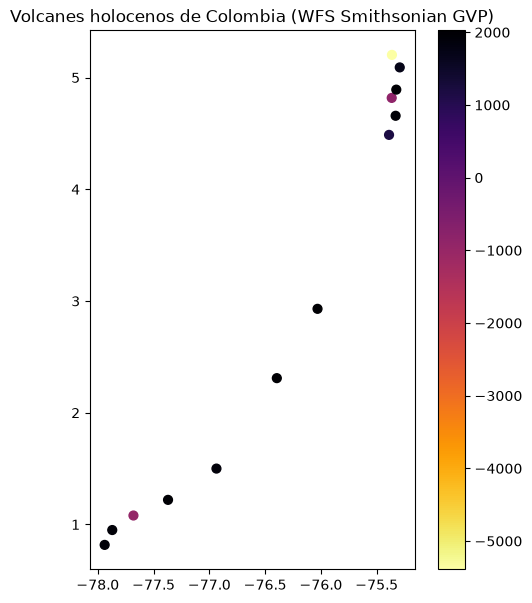

In [135]:
# 1. Guardar
volcanes.to_file('volcanes_colombia.geojson', driver='GeoJSON')

# 2. Graficar coloreando por el año de la última erupción
ax = volcanes.plot(column='Last_Eruption_Year', cmap='inferno_r', legend=True,
                   markersize=40, figsize=(6, 7))
ax.set_title('Volcanes holocenos de Colombia (WFS Smithsonian GVP)');

Un WFS también se puede consultar **sin OWSLib**, armando la petición `GetFeature` como URL. GeoPandas la lee directamente. Aquí además usamos un **filtro por atributo** (`CQL_FILTER`, propio de GeoServer):

In [136]:
# 1. Parámetros de la petición GetFeature
params = {
    'service': 'WFS',
    'version': '1.0.0',
    'request': 'GetFeature',
    'typeName': 'GVP-VOTW:Smithsonian_VOTW_Holocene_Volcanoes',
    'outputFormat': 'application/json',
    'CQL_FILTER': "Country='Ecuador'",
}

# 2. Armar la URL completa sin enviar la petición
peticion = requests.Request('GET', url_gvp, params=params)
peticion_preparada = peticion.prepare()
url = peticion_preparada.url
print(url)

# 3. GeoPandas hace la petición y lee el GeoJSON
ecuador = gpd.read_file(url)
print(len(ecuador), 'volcanes en Ecuador')
ecuador[['Volcano_Name', 'Last_Eruption_Year']].head()

https://webservices.volcano.si.edu/geoserver/GVP-VOTW/wfs?service=WFS&version=1.0.0&request=GetFeature&typeName=GVP-VOTW%3ASmithsonian_VOTW_Holocene_Volcanoes&outputFormat=application%2Fjson&CQL_FILTER=Country%3D%27Ecuador%27
35 volcanes en Ecuador


,Volcano_Name,Last_Eruption_Year
0,Galapagos Rift at 86°W,1996.0
1,Soche,-6650.0
2,Chachimbiro,-3740.0
3,Cuicocha,650.0
4,Imbabura,-5550.0


### 1.5 WFS del IGAC

El ArcGIS Server del IGAC también tiene servicios WFS, por ejemplo los **POMCAS** (Planes de Ordenación y Manejo de Cuencas). Este servidor es intermitente, por eso la celda está protegida con `try/except`.

In [ ]:
url_pomcas = 'https://mapas.igac.gov.co/server/services/ambiente/pomcas/MapServer/WFSServer'

try:
    # 1. Conectarse al WFS
    wfs_igac = WebFeatureService(url_pomcas, version='2.0.0', timeout=180)
    print(list(wfs_igac.contents))

    # 2. Pedir las entidades
    # en WFS 2.0 con EPSG:4326 el bbox va en orden (lat_min, lon_min, lat_max, lon_max)
    bbox_latlon = (5.5, -76.5, 7.0, -75.0)
    resp = wfs_igac.getfeature(typename='pomcas:pomcasaprobados', bbox=bbox_latlon, outputFormat='GEOJSON')

    # 3. Convertir en GeoDataFrame
    pomcas = gpd.read_file(io.BytesIO(resp.read()))

    # 4. Graficar
    pomcas.plot(edgecolor='k', figsize=(6, 6))

except Exception as e:
    print('El servicio del IGAC no respondió:', type(e).__name__)

## 2. APIs (Application Programming Interface)

Una [API](https://codeburst.io/the-art-of-accessing-apis-bf1a25338fac) es un intermediario que permite la comunicación entre dos aplicaciones. Las APIs web tipo **REST** reciben peticiones HTTP (`GET`, `POST`) con parámetros y devuelven, por lo general, **JSON**. Hay muchas [APIs públicas gratuitas](https://github.com/public-apis/public-apis#geocoding); varias exigen registrarse para obtener una *API key* y tienen límites de peticiones por unidad de tiempo (*rate limit*).

La librería [requests](https://requests.readthedocs.io/) es el estándar para hacer peticiones HTTP en Python. En lugar de concatenar la URL a mano, conviene pasar los parámetros como diccionario (`params`), que se encarga de codificarlos correctamente.

### 2.1 Catálogo de sismos del USGS

El [Earthquake Catalog](https://earthquake.usgs.gov/fdsnws/event/1/) del USGS implementa la especificación [FDSN Event Web Service](http://www.fdsn.org/webservices/FDSN-WS-Specifications-1.0.pdf) y permite búsquedas por región, fechas, magnitud y profundidad. Parámetros principales:

| Parámetro | Descripción |
|---|---|
| `format` | `geojson`, `csv`, `xml`, `text`, `kml` |
| `starttime`, `endtime` | fechas ISO 8601 |
| `minlatitude`, `maxlatitude`, `minlongitude`, `maxlongitude` | rectángulo |
| `latitude`, `longitude`, `maxradiuskm` | círculo |
| `minmagnitude`, `maxdepth`, `orderby`, `limit` | filtros |

In [32]:
# 1. URL base de la API
url_usgs = 'https://earthquake.usgs.gov/fdsnws/event/1/query'

# 2. Parámetros de la consulta
params = {
    'format': 'geojson',
    'starttime': '2024-01-01T00:00:00',
    'endtime': '2024-12-31T23:59:59',
    'minlatitude': bbox_colombia[1],
    'maxlatitude': bbox_colombia[3],
    'minlongitude': bbox_colombia[0],
    'maxlongitude': bbox_colombia[2],
    'minmagnitude': 2.5,
}

# 3. Hacer la petición
req = requests.get(url_usgs, params=params, timeout=120)

# 4. Revisar la respuesta
print('Código de estado:', req.status_code)
print('URL:', req.url)

Código de estado: 200
URL: https://earthquake.usgs.gov/fdsnws/event/1/query?format=geojson&starttime=2024-01-01T00%3A00%3A00&endtime=2024-12-31T23%3A59%3A59&minlatitude=-5.0&maxlatitude=13.0&minlongitude=-80.0&maxlongitude=-66.0&minmagnitude=2.5


In [33]:
# 1. Convertir la respuesta en diccionario
eq_data = req.json()

# 2. Partes del GeoJSON
print(eq_data.keys())

# 3. Metadatos de la consulta
print(eq_data['metadata'])

# 4. Primer sismo
eq_data['features'][0]

dict_keys(['type', 'metadata', 'features', 'bbox'])
{'generated': 1791318257000, 'url': 'https://earthquake.usgs.gov/fdsnws/event/1/query?format=geojson&starttime=2024-01-01T00%3A00%3A00&endtime=2024-12-31T23%3A59%3A59&minlatitude=-5.0&maxlatitude=13.0&minlongitude=-80.0&maxlongitude=-66.0&minmagnitude=2.5', 'title': 'USGS Earthquakes', 'status': 200, 'api': '2.7.0', 'count': 175}


{'type': 'Feature',
 'properties': {'mag': 4.5,
  'place': '28 km N of Dibulla, Colombia',
  'time': 1735635561553,
  'updated': 1741473554040,
  'tz': None,
  'url': 'https://earthquake.usgs.gov/earthquakes/eventpage/us6000pgmd',
  'detail': 'https://earthquake.usgs.gov/fdsnws/event/1/query?eventid=us6000pgmd&format=geojson',
  'felt': None,
  'cdi': None,
  'mmi': None,
  'alert': None,
  'status': 'reviewed',
  'tsunami': 0,
  'sig': 312,
  'net': 'us',
  'code': '6000pgmd',
  'ids': ',us6000pgmd,',
  'sources': ',us,',
  'types': ',origin,phase-data,',
  'nst': 47,
  'dmin': 0.921,
  'rms': 1.28,
  'gap': 37,
  'magType': 'mb',
  'type': 'earthquake',
  'title': 'M 4.5 - 28 km N of Dibulla, Colombia'},
 'geometry': {'type': 'Point', 'coordinates': [-73.3585, 11.5228, 10]},
 'id': 'us6000pgmd'}

El GeoJSON se convierte directamente en un `GeoDataFrame`. La tercera coordenada de cada punto es la profundidad (km) y el tiempo viene en milisegundos desde 1970:

In [34]:
# 1. Convertir la lista de features en GeoDataFrame
sismos = gpd.GeoDataFrame.from_features(eq_data['features'], crs='EPSG:4326')

# 2. La profundidad (km) es la coordenada z de cada punto
profundidades = []
for punto in sismos.geometry:
    profundidades.append(punto.z)
sismos['profundidad'] = profundidades

# 3. Convertir el tiempo (milisegundos desde 1970) en fecha
sismos['fecha'] = pd.to_datetime(sismos['time'], unit='ms')

# 4. Quedarnos con las columnas útiles
columnas = ['fecha', 'mag', 'magType', 'place', 'profundidad', 'url', 'geometry']
sismos = sismos[columnas]
print(len(sismos), 'sismos')

# 5. Los de mayor magnitud
sismos.sort_values('mag', ascending=False).head()

175 sismos


,fecha,mag,magType,place,profundidad,url,geometry
170,2024-01-19 11:26:03.598,5.6,mww,"7 km E of Cartago, Colombia",65.067,https://earthquake.usgs.gov/earthquakes/eventp...,POINT Z (-75.8481 4.7429 65.067)
98,2024-06-18 02:22:10.098,5.5,mww,"53 km SSW of Alianza Cristiana, Peru",106.228,https://earthquake.usgs.gov/earthquakes/eventp...,POINT Z (-76.671 -3.8928 106.228)
22,2024-11-08 10:37:42.623,5.1,mww,"58 km E of Puyo, Ecuador",190.812,https://earthquake.usgs.gov/earthquakes/eventp...,POINT Z (-77.4738 -1.4492 190.812)
113,2024-05-21 02:43:10.935,5.1,mww,"3 km S of Piñas, Ecuador",84.173,https://earthquake.usgs.gov/earthquakes/eventp...,POINT Z (-79.6819 -3.7141 84.173)
110,2024-05-22 05:34:19.975,5.0,mww,"63 km W of Mosquera, Colombia",10.000,https://earthquake.usgs.gov/earthquakes/eventp...,POINT Z (-79.0178 2.5123 10)


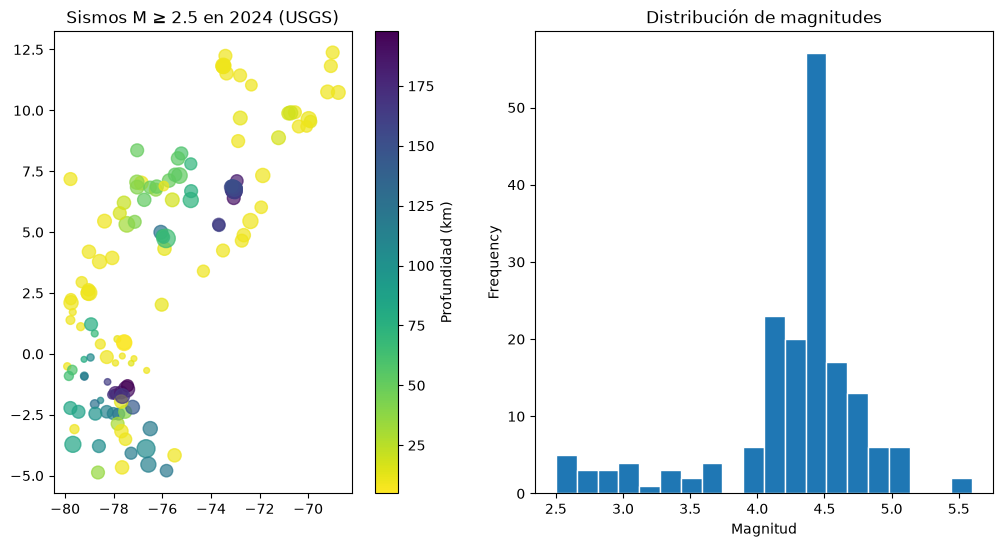

In [35]:
fig, ax = plt.subplots(1, 2, figsize=(13, 6))

# 1. Mapa: tamaño según magnitud y color según profundidad
tamano = sismos['mag'] ** 3
sismos.plot(ax=ax[0], column='profundidad', cmap='viridis_r', markersize=tamano,
            legend=True, legend_kwds={'label': 'Profundidad (km)'}, alpha=0.7)

ax[0].set_title('Sismos M ≥ 2.5 en 2024 (USGS)')

# 3. Histograma de magnitudes
sismos['mag'].plot.hist(ax=ax[1], bins=20, edgecolor='w')
ax[1].set_xlabel('Magnitud')
ax[1].set_title('Distribución de magnitudes');

In [142]:
# GeoJSON no acepta fechas: se guarda una copia con la fecha como texto
sismos_guardar = sismos.copy()
sismos_guardar['fecha'] = sismos_guardar['fecha'].astype(str)

sismos_guardar.to_file('sismos_2024.geojson', driver='GeoJSON')

Como el servicio puede responder directamente en GeoJSON, también basta con pasarle la URL a GeoPandas. El USGS además publica **feeds en tiempo real** (última hora, día, semana, mes) en [este enlace](https://earthquake.usgs.gov/earthquakes/feed/v1.0/geojson.php):

In [143]:
# 1. Leer el feed directamente desde la URL
url_feed = 'https://earthquake.usgs.gov/earthquakes/feed/v1.0/summary/4.5_week.geojson'
ultimos = gpd.read_file(url_feed)
print(len(ultimos), 'sismos M ≥ 4.5 en los últimos 7 días en el mundo')

# 2. Los de mayor magnitud
ultimos[['mag', 'place', 'geometry']].sort_values('mag', ascending=False).head()

135 sismos M ≥ 4.5 en los últimos 7 días en el mundo


,mag,place,geometry
121,6.6,"80 km ENE of Tadine, New Caledonia",POINT Z (168.61 -21.2982 10)
17,5.6,"94 km SW of Tamarindo, Costa Rica",POINT Z (-86.5063 9.7526 8)
96,5.6,"72 km ESE of Kokopo, Papua New Guinea",POINT Z (152.8611 -4.6288 69.51)
27,5.6,"74 km S of Yonakuni, Japan",POINT Z (122.9149 23.8027 10.792)
39,5.5,southern Mid-Atlantic Ridge,POINT Z (-16.0771 -35.2758 10)


## 3. OpenStreetMap con OSMnx

[OpenStreetMap](https://www.openstreetmap.org) (OSM) es una base de datos geográfica colaborativa y libre. [OSMnx](https://osmnx.readthedocs.io/) consulta la **API Overpass** de OSM y devuelve:

- límites administrativos (`geocode_to_gdf`),
- redes viales como grafos de `networkx` (`graph_from_place`, `graph_from_bbox`, `graph_from_point`),
- cualquier entidad etiquetada (`features_from_place`): edificios, parques, hospitales, ríos...

Las entidades de OSM se describen con **etiquetas** (*tags*) `clave=valor`, por ejemplo `amenity=hospital`, `leisure=park`, `building=yes`. El catálogo está en el [wiki de OSM](https://wiki.openstreetmap.org/wiki/Map_features).

> A partir de OSMnx 2.0, `geometries_from_place` pasó a llamarse `features_from_place`.

In [149]:
%pip install osmnx

  Using cached osmnx-2.1.1-py3-none-any.whl.metadata (4.7 kB)
Using cached osmnx-2.1.1-py3-none-any.whl (104 kB)
Note: you may need to restart the kernel to use updated packages.


In [36]:
import osmnx as ox

# guardar las respuestas en disco para no repetir consultas
ox.settings.use_cache = True
# no imprimir el registro de cada consulta
ox.settings.log_console = False

ox.__version__

'2.1.1'

### 3.1 Límite de Medellín

In [37]:
medellin = ox.geocode_to_gdf('Medellín, Colombia')
medellin[['display_name', 'geometry']]

,display_name,geometry
0,"Medellín, Valle de Aburrá, Antioquia, RAP del ...","POLYGON ((-75.71943 6.34041, -75.71935 6.34026..."


Área: 374.6 km²


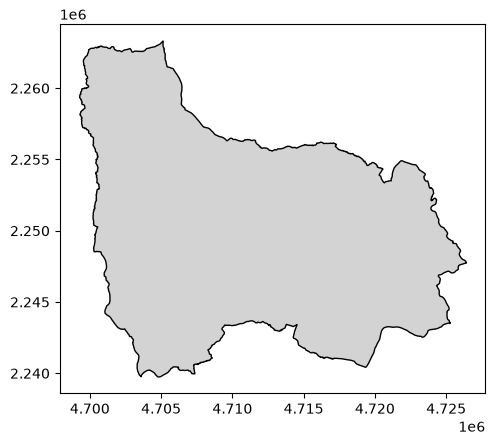

In [37]:
# 1. Reproyectar a un sistema en metros: MAGNA-SIRGAS Origen Nacional
medellin_utm = medellin.to_crs(epsg=9377)

# 2. Calcular el área en km²
area_m2 = medellin_utm.area.iloc[0]
area_km2 = area_m2 / 1e6
print(f'Área: {area_km2:.1f} km²')

# 3. Graficar
medellin_utm.plot(edgecolor='k', facecolor='lightgrey');

### 3.2 Red vial

La red vial de todo Medellín es grande (tarda varios minutos), así que trabajamos con la **comuna 14 - El Poblado**. `network_type` puede ser `drive`, `walk`, `bike`, `all`.

1432 nodos (intersecciones)
2633 arcos (tramos de vía)


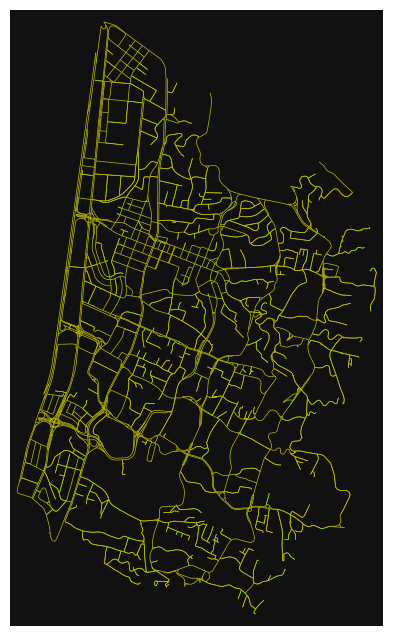

In [38]:
# 1. Descargar la red vial para carros
G = ox.graph_from_place('El Poblado, Medellín, Colombia', network_type='drive')

# 2. Tamaño de la red
print(len(G.nodes), 'nodos (intersecciones)')
print(len(G.edges), 'arcos (tramos de vía)')

# 3. Graficar
fig, ax = ox.plot_graph(G, figsize=(8, 8), node_size=0, edge_color='y', edge_linewidth=0.5)

In [154]:
# 1. Convertir el grafo en dos GeoDataFrames: nodos y arcos
nodos, vias = ox.graph_to_gdfs(G)

# 2. Ver los atributos de las vías
vias[['name', 'highway', 'length', 'geometry']].head()

name      highway     length  \
u         v          key                                                  
309026271 404910004  0                 Calle 10    secondary  42.692226   
309026273 393988726  0                 Calle 10    secondary  12.333670   
          338171294  0              Carrera 43A      primary  90.707233   
309026274 416048073  0                 Calle 10    secondary   6.740813   
          9857457488 0    [Carrera 41, Calle 9]  residential  93.965892   

                                                                   geometry  
u         v          key                                                     
309026271 404910004  0     LINESTRING (-75.57286 6.21152, -75.5725 6.21138)  
309026273 393988726  0    LINESTRING (-75.57052 6.21062, -75.57042 6.21059)  
          338171294  0    LINESTRING (-75.57052 6.21062, -75.57056 6.210...  
309026274 416048073  0    LINESTRING (-75.56877 6.20997, -75.56872 6.20994)  
          9857457488 0    LINESTRING (-75.56877 6.20997, -75.5688 6.2099...

In [155]:
# 1. Proyectar el grafo a metros (para que las longitudes sean correctas)
G_proj = ox.project_graph(G)

# 2. Calcular estadísticas
stats = ox.basic_stats(G_proj)

# 3. Mostrar algunas
print('Nodos:                ', stats['n'])
print('Arcos:                ', stats['m'])
print('Longitud total (m):   ', round(stats['street_length_total']))
print('Intersecciones:       ', stats['intersection_count'])
print('Calles por nodo (prom):', round(stats['streets_per_node_avg'], 2))

Nodos:                 1432
Arcos:                 2633
Longitud total (m):    197406
Intersecciones:        1214
Calles por nodo (prom): 2.82


In [156]:
ox.save_graph_geopackage(G, filepath='red_vial_poblado.gpkg')

### 3.3 Equipamientos y entidades

In [39]:
# 1. Descargar todo lo etiquetado leisure=park
parques = ox.features_from_place('Medellín, Colombia', tags={'leisure': 'park'})
print(parques.shape)

# 2. Tipos de geometría
parques.geom_type.value_counts()

(945, 50)


Polygon         834
Point           110
MultiPolygon      1
Name: count, dtype: int64

In [49]:
# 1. Etiquetas a buscar
etiquetas = {'amenity': ['hospital', 'school', 'university']}

# 2. Descargar
equip = ox.features_from_place('Medellín, Colombia', tags=etiquetas)

# 3. Cuántos hay de cada tipo
equip['amenity'].value_counts()

amenity
school        823
hospital       82
university     55
Name: count, dtype: int64

7331 edificios


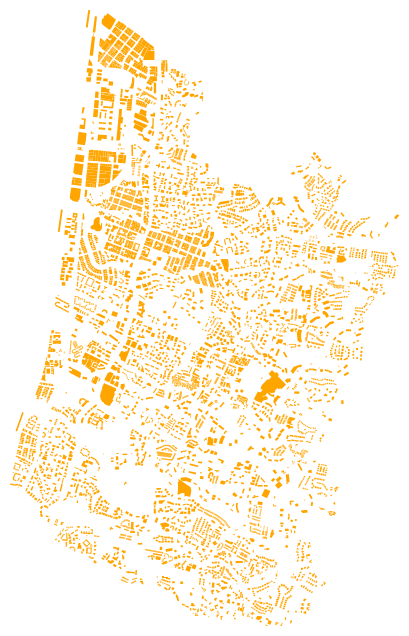

In [40]:
# 1. Descargar los edificios
edificios = ox.features_from_place('El Poblado, Medellín, Colombia', tags={'building': True})
print(len(edificios), 'edificios')

# 2. Graficar las huellas
fig, ax = ox.plot_footprints(edificios, figsize=(8, 8), color='orange', bgcolor='white')

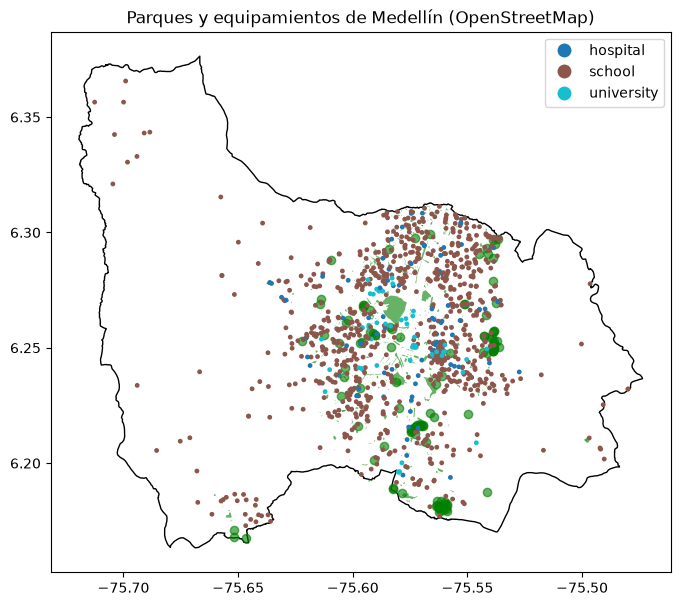

In [50]:
# 1. Pasar el índice a columnas: en osmnx 2.x es (element, id) = tipo de elemento OSM y su identificador
equip_pt = equip.reset_index()

# 2. Quedarnos con las columnas útiles
equip_pt = equip_pt[['element', 'id', 'amenity', 'name', 'geometry']].copy()

# 3. Los equipamientos vienen como punto o polígono: usamos el centroide
#    (calculado en metros y devuelto a coordenadas geográficas)
equip_utm = equip_pt.to_crs(epsg=9377)
centroides = equip_utm.centroid
equip_pt['geometry'] = centroides.to_crs(epsg=4326)

# 4. Graficar por capas
fig, ax = plt.subplots(figsize=(8, 8))
medellin.plot(ax=ax, facecolor='none', edgecolor='k')
parques.plot(ax=ax, color='green', alpha=0.6)
equip_pt.plot(ax=ax, column='amenity', markersize=6, legend=True, categorical=True)
ax.set_title('Parques y equipamientos de Medellín (OpenStreetMap)');

In [ ]:
equip_pt.to_file('equipamientos_medellin.geojson', driver='GeoJSON')

## 4. Imágenes de satélite

### 4.1 Catálogos STAC

[STAC](https://stacspec.org/) (*SpatioTemporal Asset Catalog*) es el estándar actual para catalogar imágenes de satélite. Cada escena es un **Item** (un GeoJSON con fecha, huella y metadatos como nubosidad) con **Assets** (los archivos de cada banda, normalmente como [Cloud Optimized GeoTIFF, COG](https://www.cogeo.org/)). Un COG se puede **leer parcialmente desde la nube**: solo se descargan los píxeles de la ventana que nos interesa.

Algunos catálogos STAC públicos:

- [Earth Search (Element 84, AWS)](https://earth-search.aws.element84.com/v1): Sentinel-2, Landsat, Sentinel-1, Copernicus DEM.
- [Microsoft Planetary Computer](https://planetarycomputer.microsoft.com/api/stac/v1)
- [Copernicus Data Space](https://stac.dataspace.copernicus.eu/v1)
- [USGS Landsat Look](https://landsatlook.usgs.gov/stac-server)

Parámetros de búsqueda:

* `bbox`: rectángulo `[lon_min, lat_min, lon_max, lat_max]`
* `intersects`: una geometría GeoJSON
* `datetime`: una fecha o un rango `inicio/fin`
* `query`: filtros sobre propiedades (`eq`, `lt`, `gt`, `lte`, `gte`)
* `sortby`: ordenar por una propiedad

### 4.3 pystac-client: Sentinel-2 sobre Medellín

In [2]:
%pip install pystac-client

  Using cached pystac_client-0.9.0-py3-none-any.whl.metadata (3.1 kB)
  Using cached pystac-1.15.2-py3-none-any.whl.metadata (6.3 kB)
  Using cached pystac_core-1.15.2-py3-none-any.whl.metadata (1.3 kB)
  Using cached pystac_ext_classification-2.0.1-py3-none-any.whl.metadata (2.1 kB)
  Using cached pystac_ext_datacube-2.2.1-py3-none-any.whl.metadata (1.8 kB)
  Using cached pystac_ext_eo-1.1.1-py3-none-any.whl.metadata (1.9 kB)
  Using cached pystac_ext_file-2.1.1-py3-none-any.whl.metadata (1.8 kB)
  Using cached pystac_ext_grid-1.1.1-py3-none-any.whl.metadata (1.9 kB)
  Using cached pystac_ext_item_assets-1.0.1-py3-none-any.whl.metadata (1.9 kB)
  Using cached pystac_ext_label-1.0.2-py3-none-any.whl.metadata (1.9 kB)
  Using cached pystac_ext_mgrs-1.0.1-py3-none-any.whl.metadata (1.8 kB)
  Using cached pystac_ext_mlm-1.4.1-py3-none-any.whl.metadata (2.2 kB)
  Using cached pystac_ext_pointcloud-1.0.1-py3-none-any.whl.metadata (1.8 kB)
  Using cached pystac_ext_projection-2.0.1-py3-none-

In [8]:
from pystac_client import Client

# 1. Abrir el catálogo
catalogo = Client.open('https://earth-search.aws.element84.com/v1')

# 2. Listar las colecciones disponibles
colecciones = []
for c in catalogo.get_collections():
    colecciones.append(c.id)
colecciones

['sentinel-2-pre-c1-l2a',
 'cop-dem-glo-30',
 'naip',
 'cop-dem-glo-90',
 'landsat-c2-l2',
 'sentinel-2-l2a',
 'sentinel-2-l1c',
 'sentinel-2-c1-l2a',
 'sentinel-1-grd']

In [9]:
# 1. Área de interés: centro de Medellín [lon_min, lat_min, lon_max, lat_max]
aoi = [-75.63, 6.20, -75.53, 6.30]

# 2. Filtros por propiedades
filtros = {
    'eo:cloud_cover': {'lt': 30},                 # menos de 30 % de nubes
    's2:nodata_pixel_percentage': {'lt': 20},     # evita escenas en el borde de la franja
}

# 3. Orden: primero las de menor nubosidad
orden = [{'field': 'properties.eo:cloud_cover', 'direction': 'asc'}]

# 4. Definir la búsqueda
busqueda = catalogo.search(collections=['sentinel-2-l2a'],
                           bbox=aoi,
                           datetime='2023-01-01/2024-12-31',
                           query=filtros,
                           sortby=orden,
                           max_items=20)

# 5. Ejecutarla y guardar los resultados en una lista
items = list(busqueda.items())
print(len(items), 'escenas')

20 escenas


In [8]:
# 1. Cada item es un GeoJSON: convertirlos en diccionarios
items_dict = []
for it in items:
    items_dict.append(it.to_dict())

# 2. Pasarlos a un GeoDataFrame (la geometría es la huella de la escena)
escenas = gpd.GeoDataFrame.from_features(items_dict, crs='EPSG:4326')

# 3. Ver las propiedades principales
escenas[['datetime', 'eo:cloud_cover', 's2:nodata_pixel_percentage', 'grid:code', 'geometry']].head()

,datetime,eo:cloud_cover,s2:nodata_pixel_percentage,grid:code,geometry
0,2024-01-23T15:31:32.913000Z,2.536727,8.007648,MGRS-18NVM,"POLYGON ((-75.71677 6.33254, -75.72901 6.26766..."
1,2024-08-15T15:31:34.792000Z,6.118389,8.061894,MGRS-18NVM,"POLYGON ((-75.71605 6.33254, -75.72523 6.28224..."
2,2024-06-01T15:31:34.819000Z,6.833547,7.741541,MGRS-18NVM,"POLYGON ((-75.71957 6.33253, -75.73236 6.26811..."
3,2023-08-26T15:31:38.063000Z,7.953341,7.507553,MGRS-18NVM,"POLYGON ((-75.72229 6.33253, -75.72923 6.2948,..."
4,2024-08-30T15:31:36.361000Z,11.002751,7.167697,MGRS-18NVM,"POLYGON ((-75.72599 6.33253, -75.73932 6.26944..."


In [9]:
# 1. Tomar la primera escena (la de menor nubosidad)
item = items[0]

# 2. Sus propiedades
print('Id:    ', item.id)
print('Fecha: ', item.datetime)
print('Nubes: ', item.properties['eo:cloud_cover'])

# 3. Los archivos (assets) disponibles: una banda por archivo
list(item.assets)

Id:     S2B_18NVM_20240123_0_L2A
Fecha:  2024-01-23 15:31:32.913000+00:00
Nubes:  2.536727


['aot',
 'blue',
 'coastal',
 'granule_metadata',
 'green',
 'nir',
 'nir08',
 'nir09',
 'red',
 'rededge1',
 'rededge2',
 'rededge3',
 'scl',
 'swir16',
 'swir22',
 'thumbnail',
 'tileinfo_metadata',
 'visual',
 'wvp',
 'aot-jp2',
 'blue-jp2',
 'coastal-jp2',
 'green-jp2',
 'nir-jp2',
 'nir08-jp2',
 'nir09-jp2',
 'red-jp2',
 'rededge1-jp2',
 'rededge2-jp2',
 'rededge3-jp2',
 'scl-jp2',
 'swir16-jp2',
 'swir22-jp2',
 'visual-jp2',
 'wvp-jp2']

In [12]:
url_miniatura = item.assets['thumbnail'].href
print(url_miniatura)
Image(url=url_miniatura, width=350)

https://sentinel-cogs.s3.us-west-2.amazonaws.com/sentinel-s2-l2a-cogs/18/N/VM/2024/1/S2B_18NVM_20240123_0_L2A/thumbnail.jpg


Leer **solo la ventana** del área de interés desde el COG en la nube (no se descarga la escena completa de ~1 GB):

In [69]:
import os
import site
import sys

user_site = os.path.normcase(os.path.normpath(site.getusersitepackages()))
sys.path = [
    path for path in sys.path
    if os.path.normcase(os.path.normpath(path)) != user_site
]

import rasterio
from rasterio.warp import transform_bounds
from rasterio.windows import from_bounds as window_from_bounds


def leer_ventana(href, bbox_ll):
    # 1. Abrir el COG en la nube (todavía no se descargan píxeles)
    with rasterio.open(href) as src:
        # 2. Pasar el bbox de grados al sistema de la imagen (UTM)
        bb = transform_bounds('EPSG:4326', src.crs, *bbox_ll)
        # 3. Convertir el bbox en una ventana (filas y columnas)
        win = window_from_bounds(*bb, transform=src.transform)
        # 4. Leer solo esa ventana
        datos = src.read(window=win)
        # 5. Transformación afín de la ventana (para georreferenciarla después)
        transform_ventana = src.window_transform(win)
        crs_imagen = src.crs
    return datos, transform_ventana, crs_imagen


# los archivos son públicos: no se necesitan credenciales de AWS
with rasterio.Env(AWS_NO_SIGN_REQUEST='YES'):
    # imagen en color verdadero (3 bandas)
    rgb, tr, crs = leer_ventana(item.assets['visual'].href, aoi)
    # banda roja
    red, _, _ = leer_ventana(item.assets['red'].href, aoi)
    # banda infrarrojo cercano
    nir, _, _ = leer_ventana(item.assets['nir'].href, aoi)

print(rgb.shape)
print(crs)

NameError: name 'item' is not defined

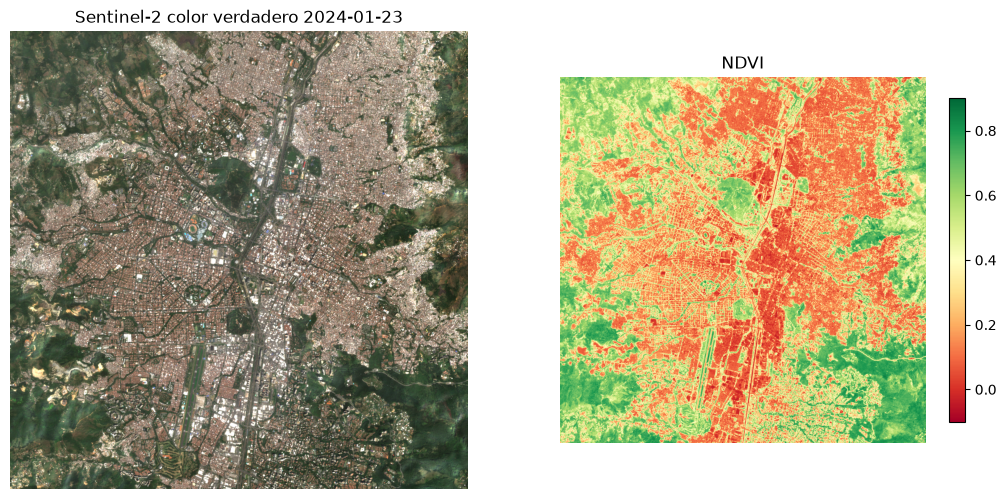

In [17]:
# 1. Tomar la única banda de cada arreglo y pasar a decimales
red = red[0].astype('float32')
nir = nir[0].astype('float32')

# 2. Calcular el NDVI (el 1e-6 evita dividir por cero)
ndvi = (nir - red) / (nir + red + 1e-6)

# 3. Reordenar la imagen RGB a (filas, columnas, bandas) para matplotlib
rgb_plot = np.moveaxis(rgb, 0, -1)

# 4. Graficar
fig, ax = plt.subplots(1, 2, figsize=(13, 6))

ax[0].imshow(rgb_plot)
ax[0].set_title(f'Sentinel-2 color verdadero {item.datetime:%Y-%m-%d}')
ax[0].set_axis_off()

im = ax[1].imshow(ndvi, cmap='RdYlGn', vmin=-0.1, vmax=0.9)
ax[1].set_title('NDVI')
ax[1].set_axis_off()
fig.colorbar(im, ax=ax[1], shrink=0.7);

In [18]:
# guardar el recorte como GeoTIFF
n_bandas = rgb.shape[0]
alto = rgb.shape[1]
ancho = rgb.shape[2]

with rasterio.open('s2_medellin_visual.tif', 'w', driver='GTiff',
                   height=alto, width=ancho, count=n_bandas, dtype=rgb.dtype,
                   crs=crs, transform=tr) as dst:
    dst.write(rgb)

Visor interactivo de las miniaturas de las escenas encontradas (requiere `ipywidgets`):

In [10]:
from ipywidgets import interact
from IPython.display import Image, display


def ver_escena(i=0):
    # 1. Tomar la escena i
    it = items[i]
    # 2. Imprimir sus datos
    fecha = it.datetime.strftime('%Y-%m-%d')
    nubes = it.properties['eo:cloud_cover']
    print(f'{it.id}  fecha={fecha}  nubes={nubes:.1f}%')
    # 3. Mostrar la miniatura
    display(Image(url=it.assets['thumbnail'].href, width=350))


interact(ver_escena, i=(0, len(items) - 1));

interactive(children=(IntSlider(value=0, description='i', max=19), Output()), _dom_classes=('widget-interact',…

### Copernicus Data Space Ecosystem

[Copernicus Data Space Ecosystem (CDSE)](https://dataspace.copernicus.eu/)

La **API OData del CDSE** (la búsqueda es libre; la descarga exige una cuenta gratuita):

In [11]:
odata = 'https://catalogue.dataspace.copernicus.eu/odata/v1/Products'

# 1. Filtro en lenguaje OData (cada línea es una condición)
filtro = (
    "Collection/Name eq 'SENTINEL-2' "
    "and OData.CSC.Intersects(area=geography'SRID=4326;POINT(-75.58 6.25)') "
    "and ContentDate/Start gt 2024-01-01T00:00:00.000Z "
    "and ContentDate/Start lt 2024-12-31T00:00:00.000Z "
    "and Attributes/OData.CSC.StringAttribute/any(att:att/Name eq 'productType' and att/OData.CSC.StringAttribute/Value eq 'S2MSI2A') "
    "and Attributes/OData.CSC.DoubleAttribute/any(att:att/Name eq 'cloudCover' and att/OData.CSC.DoubleAttribute/Value lt 20.0)"
)

# 2. Parámetros de la petición
params = {
    '$filter': filtro,
    '$orderby': 'ContentDate/Start desc',
    '$top': 20,
    '$expand': 'Attributes',      # incluir los atributos (nubosidad, etc.)
}

# 3. Hacer la petición
r = requests.get(odata, params=params, timeout=120)
print('Código de estado:', r.status_code)

# 4. Convertir la lista de productos en DataFrame
contenido = r.json()
productos = pd.DataFrame(contenido['value'])


# 5. Extraer la nubosidad de la lista de atributos de cada producto
def nubosidad(atributos):
    for a in atributos:
        if a['Name'] == 'cloudCover':
            return a['Value']
    return None


productos['nubes'] = productos['Attributes'].apply(nubosidad)

# 6. Tamaño en MB
productos['MB'] = (productos['ContentLength'] / 1e6).round()

# 7. Ordenar por nubosidad
productos[['Id', 'Name', 'nubes', 'MB']].sort_values('nubes').head()

Código de estado: 200


,Id,Name,nubes,MB
13,24ede061-7621-4c06-9d97-2910707616db,S2A_MSIL2A_20240729T153631_N0511_R068_T18NVN_2...,2.667730,634.0
1,de13d966-890a-4255-bdbe-d59159ece27f,S2B_MSIL2A_20241208T152659_N0511_R025_T18NVN_2...,3.273594,972.0
7,a5d93db8-352c-4419-8c0c-b173fa2c062b,S2A_MSIL2A_20240818T153631_N0511_R068_T18NVM_2...,4.086335,381.0
9,1ac9710b-abbd-4afa-bab6-10008946df67,S2A_MSIL2A_20240815T152651_N0511_R025_T18NVM_2...,6.118389,1157.0
10,aafb021f-9e9e-40b3-b6cb-5bf8ff1f38b4,S2A_MSIL2A_20240815T152651_N0511_R025_T18NVN_2...,7.433095,951.0


In [12]:
# Descarga (requiere cuenta en https://dataspace.copernicus.eu). Cambiar DESCARGAR a True para ejecutar.
DESCARGAR = False

if DESCARGAR:
    import os
    from getpass import getpass

    # 1. Credenciales: primero de variables de entorno, si no, se piden
    usuario = os.environ.get('CDSE_USER') or input('Usuario CDSE: ')
    clave = os.environ.get('CDSE_PASSWORD') or getpass('Clave CDSE: ')

    # 2. Pedir un token de acceso (petición POST con usuario y clave en el cuerpo)
    url_token = 'https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token'
    datos = {
        'client_id': 'cdse-public',
        'grant_type': 'password',
        'username': usuario,
        'password': clave,
    }
    resp_token = requests.post(url_token, data=datos, timeout=60)
    token = resp_token.json()['access_token']

    # 3. Elegir el producto con menos nubes
    productos_ordenados = productos.sort_values('nubes')
    pid = productos_ordenados.iloc[0]['Id']

    # 4. URL de descarga y encabezado de autorización con el token
    url = f'https://download.dataspace.copernicus.eu/odata/v1/Products({pid})/$value'
    encabezados = {'Authorization': f'Bearer {token}'}

    # 5. Descargar por partes (stream=True) para no cargar el archivo completo en memoria
    with requests.get(url, headers=encabezados, stream=True, timeout=600) as resp:
        resp.raise_for_status()
        with open(out / f'{pid}.zip', 'wb') as f:
            for chunk in resp.iter_content(chunk_size=1024 * 1024):   # bloques de 1 MB
                f.write(chunk)

## 5. Geocodificación con Nominatim

**Geocodificar** es convertir un nombre o una dirección en coordenadas; la **geocodificación inversa** convierte coordenadas en una dirección. [Geopy](https://geopy.readthedocs.io/) ofrece una interfaz común para muchos servicios (Google, Bing, ArcGIS, Nominatim...), cada uno con sus propios términos de uso, cuotas y precios.

[Nominatim](https://nominatim.org/) es el geocodificador de OpenStreetMap: gratuito pero con una [política de uso](https://operations.osmfoundation.org/policies/nominatim/) estricta:

* máximo **1 petición por segundo**;
* `user_agent` obligatorio, que identifique su aplicación (no use el valor por defecto ni copie el de otro);
* nada de geocodificación masiva (para eso, instale su propio servidor o use un servicio comercial).

Parámetros de interés: `exactly_one`, `language` (`'es'`), `country_codes` (`'co'`), `featuretype` (`country`, `state`, `city`, `settlement`), `timeout`.

In [13]:
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter

geolocator = Nominatim(user_agent='curso-analisis-geoespacial-unal', timeout=20)

In [14]:
# 1. Geocodificar
loc = geolocator.geocode('Facultad de Minas, Medellín', country_codes='co', language='es')

# 2. Resultado
print(loc.address)
print(loc.latitude, loc.longitude)

# 3. Respuesta completa del servidor
loc.raw

Facultad de Minas, Carrera 78A, San Germán, Comuna 7 - Robledo, Perímetro Urbano Medellín, Medellín, Valle de Aburrá, Antioquia, RAP del Agua y la Montaña, 050034, Colombia
6.2734234 -75.5924353


{'place_id': 308926764,
 'licence': 'Data © OpenStreetMap contributors, ODbL 1.0. http://osm.org/copyright',
 'osm_type': 'way',
 'osm_id': 140267859,
 'lat': '6.2734234',
 'lon': '-75.5924353',
 'class': 'amenity',
 'type': 'university',
 'place_rank': 30,
 'importance': 6.934843976496555e-05,
 'addresstype': 'amenity',
 'name': 'Facultad de Minas',
 'display_name': 'Facultad de Minas, Carrera 78A, San Germán, Comuna 7 - Robledo, Perímetro Urbano Medellín, Medellín, Valle de Aburrá, Antioquia, RAP del Agua y la Montaña, 050034, Colombia',
 'boundingbox': ['6.2730488', '6.2737895', '-75.5928157', '-75.5919578']}

In [15]:
# 1. Pedir varias coincidencias
resultados = geolocator.geocode('El Líbano', country_codes='co', exactly_one=False, limit=5)

# 2. Recorrerlas
for l in resultados:
    print(l.address, '->', l.latitude, l.longitude)

El Líbano, La Charrapala, Andes, Suroeste, Antioquia, RAP del Agua y la Montaña, Colombia -> 5.647463 -75.9033428
El Líbano, Zona 3 La Calera, La Calera, Guavio, Cundinamarca, RAP (Especial) Central, Colombia -> 4.6587493 -74.0071407
El Líbano, Florida, Sur, Valle del Cauca, RAP Pacífico, Colombia -> 3.2715926 -76.216197
El Líbano, Florida, Sur, Valle del Cauca, RAP Pacífico, 191520, Colombia -> 3.2736546 -76.2155242
El Líbano, Rosas, Macizo, Cauca, RAP Pacífico, Colombia -> 2.2672732 -76.7119209


In [ ]:
# consulta estructurada: cada parte de la dirección por separado
consulta = {'city': 'Medellín', 'state': 'Antioquia', 'country': 'Colombia'}

geolocator.geocode(consulta, featuretype='city')

In [ ]:
# geocodificación inversa: de coordenadas (lat, lon) a dirección
ubicacion = geolocator.reverse((6.2742, -75.5927), language='es')

ubicacion.address

Para geocodificar una lista se usa `RateLimiter`, que respeta el límite de 1 petición/segundo. Observe que la **nomenclatura urbana colombiana** (`Calle 59A # 63-20`) no siempre se resuelve bien en OSM: Nominatim encuentra la calle, pero no el predio. Siempre hay que revisar la calidad de la geocodificación.

In [57]:
# 1. Lista de sitios
sitios = pd.DataFrame({'sitio': [
    'Universidad Nacional de Colombia, Medellín',
    'Parque Explora, Medellín',
    'Carrera 80 # 65-223, Medellín, Colombia',
    'Calle 59A # 63-20, Medellín',
    'Santa Elena, Medellín',
]})

# 2. Función que respeta el límite de 1 petición por segundo
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1.1)

# 3. Geocodificar cada sitio y guardar los resultados
direcciones = []
latitudes = []
longitudes = []

for s in sitios['sitio']:
    l = geocode(s, country_codes='co', language='es')
    if l is None:                     # no se encontró
        direcciones.append(None)
        latitudes.append(np.nan)
        longitudes.append(np.nan)
    else:
        direcciones.append(l.address)
        latitudes.append(l.latitude)
        longitudes.append(l.longitude)

sitios['direccion'] = direcciones
sitios['lat'] = latitudes
sitios['lon'] = longitudes

# 4. Convertir en GeoDataFrame
geometria = gpd.points_from_xy(sitios['lon'], sitios['lat'])
sitios_gdf = gpd.GeoDataFrame(sitios, geometry=geometria, crs='EPSG:4326')
sitios_gdf

,sitio,direccion,lat,lon,geometry
0,"Universidad Nacional de Colombia, Medellín","Universidad Nacional de Colombia, Calle 59A, N...",6.262958,-75.577170,POINT (-75.57717 6.26296)
1,"Parque Explora, Medellín","Parque Explora, Calle 77, Miranda, Comuna 4 - ...",6.270621,-75.565575,POINT (-75.56558 6.27062)
2,"Carrera 80 # 65-223, Medellín, Colombia","Portería Universidad Nacional de Colombia, # 6...",6.274065,-75.592554,POINT (-75.59255 6.27406)
3,"Calle 59A # 63-20, Medellín","Calle 59A, Boston, Comuna 10 - La Candelaria, ...",6.250668,-75.554934,POINT (-75.55493 6.25067)
4,"Santa Elena, Medellín","Santa Elena, Medellín, Valle de Aburrá, Antioq...",6.210517,-75.498041,POINT (-75.49804 6.21052)


El servicio de geocodificación de **Google Maps** (de pago, con crédito mensual gratuito) se explica en el notebook `05_DownloadData_Vector`. OSMnx también geocodifica con Nominatim: `ox.geocode('Medellín, Colombia')`.

## 6. Mapas con capas de fondo y mapas interactivos

Ahora usamos lo descargado (volcanes, sismos, equipamientos, sitios) y los geoservicios (WMS/WMTS) para construir mapas con distintas librerías:

| Librería | Tipo | Fondo | Salida |
|---|---|---|---|
| contextily | estático (matplotlib) | teselas XYZ | figura / GeoTIFF |
| folium | interactivo (Leaflet) | XYZ, WMS | HTML |
| Bokeh | interactivo | `WMTSTileSource` | HTML |
| gmplot | interactivo | Google Maps (API key) | HTML |
| plotly | interactivo (MapLibre) | estilos, XYZ, WMS | HTML |
| Basemap | estático (matplotlib) | relieve, costas | figura |
| Leaflet | interactivo (JavaScript) | XYZ, WMS | HTML |

### 6.1 Contextily

Muchos datos pierden contexto cuando se muestran solos. [contextily](https://contextily.readthedocs.io) descarga teselas de servidores XYZ y las pone como fondo de una figura de matplotlib. Las teselas están en Web Mercator (`EPSG:3857`): o se reproyectan los datos, o se indica el `crs` a `add_basemap`.

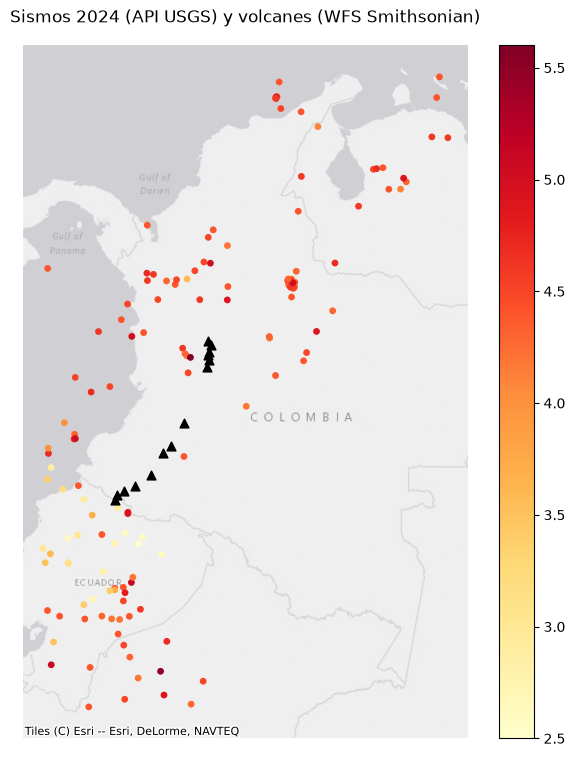

In [31]:
import contextily as cx

# 1. Reproyectar a Web Mercator (el sistema de las teselas)
sismos_wm = sismos.to_crs(epsg=3857)
volcanes_wm = volcanes.to_crs(epsg=3857)

# 2. Graficar los datos
ax = sismos_wm.plot(figsize=(8, 9), column='mag', cmap='YlOrRd', markersize=15, legend=True)
volcanes_wm.plot(ax=ax, marker='^', color='k', markersize=40)

# 3. Agregar el mapa de fondo
cx.add_basemap(ax, source=cx.providers.Esri.WorldGrayCanvas)

ax.set_axis_off()
ax.set_title('Sismos 2024 (API USGS) y volcanes (WFS Smithsonian)');

> **Ojo con las políticas de uso de las teselas.** No todos los proveedores sirven para todo:
> - Los servidores de **OpenStreetMap** (`tile.openstreetmap.org`) son mantenidos por voluntarios y **bloquean** (error 403, imagen *Access blocked*) las descargas desde scripts como contextily. En el navegador (folium, Leaflet, plotly) sí funcionan para uso moderado.
> - Los fondos de **CARTO** (`CartoDB.Positron`, `DarkMatter`, `Voyager`) ahora exigen **API key**; sin ella aparecen con la marca *API KEY REQUIRED*.
> - Los de **Esri** y **OpenTopoMap** funcionan sin registro (citando la fuente).
>
> Si un mapa sale con marcas de agua o bloqueos, cambie de proveedor.

In [32]:
# proveedores disponibles (vía xyzservices)
print(list(cx.providers.keys()))

# mapas que ofrece Esri
print(list(cx.providers.Esri.keys()))

['OpenStreetMap', 'MapTilesAPI', 'OpenSeaMap', 'OPNVKarte', 'OpenTopoMap', 'OpenRailwayMap', 'OpenFireMap', 'SafeCast', 'Stadia', 'Thunderforest', 'BaseMapDE', 'CyclOSM', 'Jawg', 'MapBox', 'MapTiler', 'TomTom', 'Esri', 'OpenWeatherMap', 'HERE', 'FreeMapSK', 'MtbMap', 'CartoDB', 'HikeBike', 'BasemapAT', 'nlmaps', 'NASAGIBS', 'NLS', 'JusticeMap', 'GeoportailFrance', 'OneMapSG', 'USGS', 'WaymarkedTrails', 'OpenAIP', 'OpenSnowMap', 'AzureMaps', 'SwissFederalGeoportal', 'TopPlusOpen', 'Gaode', 'Strava', 'OrdnanceSurvey', 'UN']
['WorldStreetMap', 'WorldTopoMap', 'WorldImagery', 'WorldTerrain', 'WorldShadedRelief', 'WorldPhysical', 'OceanBasemap', 'NatGeoWorldMap', 'WorldGrayCanvas', 'ArcticImagery', 'ArcticOceanBase', 'ArcticOceanReference', 'AntarcticImagery', 'AntarcticBasemap']


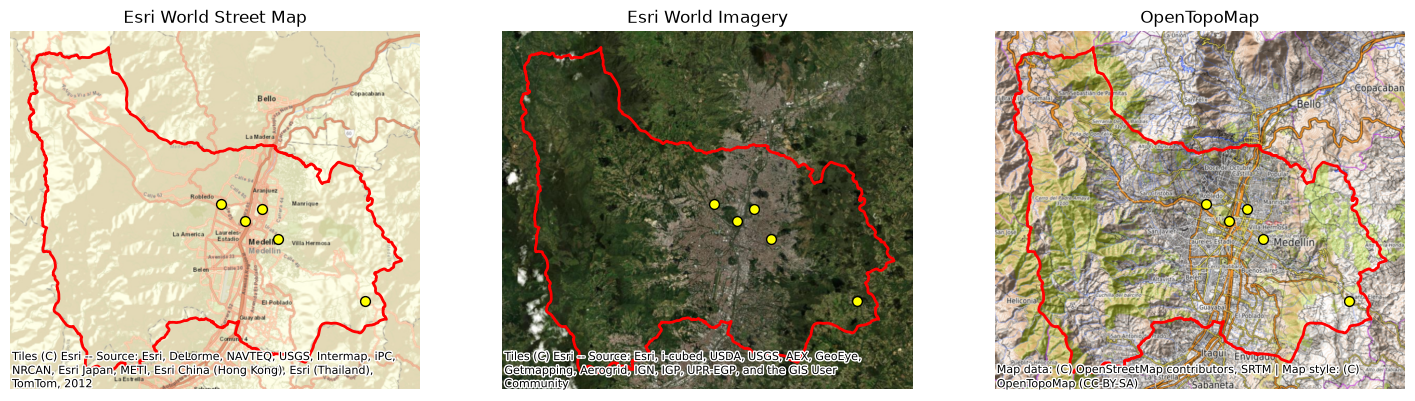

In [58]:
# 1. Fuentes a comparar
fuentes = {
    'Esri World Street Map': cx.providers.Esri.WorldStreetMap,
    'Esri World Imagery': cx.providers.Esri.WorldImagery,
    'OpenTopoMap': cx.providers.OpenTopoMap,
}

fig, ax = plt.subplots(1, 3, figsize=(18, 6))

# 2. Un mapa por fuente
i = 0
for nombre, fuente in fuentes.items():
    medellin.plot(ax=ax[i], facecolor='none', edgecolor='red', linewidth=2)
    sitios_gdf.plot(ax=ax[i], color='yellow', edgecolor='k', markersize=50)
    cx.add_basemap(ax[i], crs=medellin.crs, source=fuente)
    ax[i].set_title(nombre)
    ax[i].set_axis_off()
    i = i + 1

Cualquier plantilla XYZ sirve como fuente, por ejemplo el **WMTS de la NASA** que construimos en la sección 1.3:

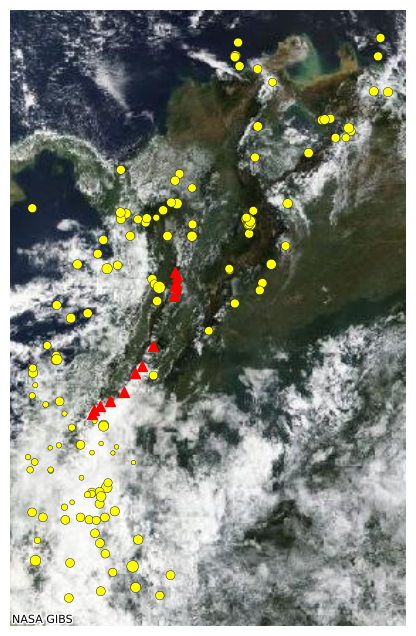

In [67]:
# 1. Tamaño de los puntos según la magnitud
tamano = sismos['mag'] ** 2.5

# 2. Graficar los datos en Web Mercator
ax = sismos_wm.plot(figsize=(7, 8), color='yellow', edgecolor='k', linewidth=0.3, markersize=tamano)
volcanes_wm.plot(ax=ax, marker='^', color='red', markersize=50)

# 3. Fondo: plantilla XYZ del WMTS de la NASA
cx.add_basemap(ax, source=gibs_xyz, zoom=5, attribution='NASA GIBS')
ax.set_axis_off();

contextily también **descarga las teselas como raster georreferenciado** (`bounds2raster`):

In [70]:
# 1. Descargar las teselas del bbox y guardarlas como GeoTIFF
ruta_tif = 'aburra_esri.tif'
img, ext = cx.bounds2raster(*bbox_aburra, path=str(ruta_tif), zoom=12,
                            source=cx.providers.Esri.WorldImagery, ll=True)
print(img.shape)

# 2. Verificar que el archivo quedó georreferenciado
with rasterio.open(ruta_tif) as src:
    print(src.crs)
    print(src.bounds)

(1536, 1536, 4)
EPSG:3857
BoundingBox(left=-8433775.06213028, bottom=665327.0034512447, right=-8375071.424407263, top=724030.6411742608)


### 6.2 Folium

[Folium](https://python-visualization.github.io/folium/) es un *wrapper* de Python para **Leaflet.js**. Permite combinar teselas XYZ, capas **WMS** y datos vectoriales (GeoJSON / GeoDataFrame) en un mapa interactivo con control de capas.

In [42]:
import folium
from folium import plugins

# Fondos XYZ
url_esri_gris = 'https://server.arcgisonline.com/ArcGIS/rest/services/Canvas/World_Light_Gray_Base/MapServer/tile/{z}/{y}/{x}'
url_esri_imagen = 'https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}'



In [10]:
m = folium.Map(location=[6.25, -75.58], zoom_start=11, tiles=url_esri_gris, attr='Esri', height=600)
m

In [11]:
m = folium.Map(location=[6.25, -75.58], zoom_start=11, tiles=url_esri_imagen, attr='Esri', height=600)
m

In [13]:
# 3. Capas WMS del IGAC
url_srtm = "https://mapas.igac.gov.co/server/services/relieve/srtm30metros/MapServer/WMSServer"

m = folium.Map(location=[6.25, -75.58], zoom_start=11, tiles=url_esri_imagen, attr='Esri', height=600)

srtm_wms = folium.WmsTileLayer(url=url_srtm, layers='0', fmt='image/png', transparent=True,
                               name='SRTM 30 m (WMS IGAC)', attr='IGAC', opacity=0.6, show=True)
srtm_wms.add_to(m)

folium.LayerControl(collapsed=False).add_to(m)
m


In [20]:
# 4. Límite de Medellín
m = folium.Map(location=[6.25, -75.58], zoom_start=11, tiles=url_esri_imagen, attr='Esri', height=600)
estilo_limite = {'fill': True, 'color': 'black', 'weight': 2}
limite = folium.GeoJson(medellin, name='Límite Medellín (OSM)',
                        style_function=lambda f: estilo_limite)
limite.add_to(m)

m


In [ ]:
m.save('mapa_folium.html')

Mapa de sismos con tamaño proporcional a la magnitud y un mapa de calor:

In [43]:
# 1. Mapa con fondo oscuro
url_esri_oscuro = 'https://server.arcgisonline.com/ArcGIS/rest/services/Canvas/World_Dark_Gray_Base/MapServer/tile/{z}/{y}/{x}'
m2 = folium.Map(location=[4.5, -74], zoom_start=6, tiles=url_esri_oscuro, attr='Esri')

# 2. Un círculo por sismo, con radio según la magnitud y una ventana emergente
for _, r in sismos.iterrows():
    ubicacion = [r.geometry.y, r.geometry.x]
    radio = r['mag'] ** 1.5

    fecha = r['fecha'].strftime('%Y-%m-%d')
    texto = (f"<b>M {r['mag']}</b><br>{r['place']}<br>{fecha}<br>"
             f"Prof.: {r['profundidad']:.0f} km<br>"
             f"<a href='{r['url']}' target='_blank'>USGS</a>")
    ventana = folium.Popup(texto, max_width=250)

    circulo = folium.CircleMarker(ubicacion, radius=radio, color='orange', weight=1,
                                  fill=True, fill_opacity=0.5, popup=ventana)
    circulo.add_to(m2)

# 3. Mapa de calor: lista de [lat, lon, peso]
puntos_calor = []
for punto, mag in zip(sismos.geometry, sismos['mag']):
    puntos_calor.append([punto.y, punto.x, mag])

plugins.HeatMap(puntos_calor, name='Densidad', radius=20, show=False).add_to(m2)

# 4. Volcanes desde el GeoDataFrame, con etiqueta al pasar el mouse
marcador = folium.CircleMarker(radius=6, color='black', weight=1, fill_color='red', fill_opacity=1)
etiqueta = folium.GeoJsonTooltip(['Volcano_Name', 'Last_Eruption_Year'], aliases=['Volcán', 'Última erupción'])

capa_volcanes = folium.GeoJson(volcanes[['Volcano_Name', 'Last_Eruption_Year', 'geometry']],
                               name='Volcanes', marker=marcador, tooltip=etiqueta)
capa_volcanes.add_to(m2)

# 5. Control de capas
folium.LayerControl().add_to(m2)
m2

### 6.3 Bokeh: `TileSource`

[Bokeh](https://bokeh.org/) dibuja gráficos interactivos en el navegador. Para mapas ofrece las [tile sources](https://docs.bokeh.org/en/latest/docs/user_guide/topics/geo.html#tile-provider-maps), en particular `WMTSTileSource`, que superpone datos sobre las teselas de **cualquier servidor** XYZ/WMTS (OSM, ESRI, NASA, servidores propios). Bokeh trabaja en Web Mercator, así que los datos se reproyectan a `EPSG:3857`.

> En Bokeh ≥ 3 la forma corta es `p.add_tile(xyz.Esri.WorldGrayCanvas)` o `p.add_tile('Esri.WorldGrayCanvas')` (proveedores de `xyzservices`); el antiguo módulo `bokeh.tile_providers` fue eliminado. En la plantilla de `WMTSTileSource` las variables van en mayúscula: `{Z}/{Y}/{X}`.

In [45]:
from bokeh.io import output_notebook, show
from bokeh.plotting import figure
from bokeh.models import WMTSTileSource, ColumnDataSource, HoverTool
import xyzservices.providers as xyz

# mostrar los gráficos de Bokeh dentro del notebook
output_notebook()

Loading BokehJS ...

In [46]:
# 1. Reproyectar a Web Mercator
eq = sismos.to_crs(epsg=3857)

# 2. Datos para Bokeh: un diccionario de columnas
datos = {
    'x': eq.geometry.x,
    'y': eq.geometry.y,
    'mag': eq['mag'],
    'size': eq['mag'] ** 2,
    'lugar': eq['place'],
    'prof': eq['profundidad'].round(0),
}
src = ColumnDataSource(datos)

# 3. Figura con la extensión de los datos y ejes en Mercator
xmin, ymin, xmax, ymax = eq.total_bounds
p = figure(x_range=(xmin, xmax), y_range=(ymin, ymax),
           x_axis_type='mercator', y_axis_type='mercator',
           width=700, height=750,
           title='Sismos 2024 sobre imagen satelital (WMTSTileSource)')

# 4. Fondo: servidor de teselas de Esri
url_teselas = 'https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{Z}/{Y}/{X}.jpg'
esri = WMTSTileSource(url=url_teselas, attribution='Esri, Maxar, Earthstar Geographics')
p.add_tile(esri)

# 5. Puntos
p.scatter('x', 'y', size='size', source=src, fill_color='orange', fill_alpha=0.6, line_color='white')

# 6. Información al pasar el mouse
info = HoverTool(tooltips=[('Lugar', '@lugar'), ('Magnitud', '@mag'), ('Profundidad (km)', '@prof')])
p.add_tools(info)

show(p)

In [52]:
from bokeh.io import output_notebook, show
from bokeh.plotting import figure
from bokeh.models import ColumnDataSource, HoverTool
import xyzservices.providers as xyz
output_notebook()

# 1. Reproyectar a Web Mercator
eqp = equip_pt.to_crs(epsg=3857)
medellin_wm = medellin.to_crs(epsg=3857)

# 2. Figura con la extensión de Medellín
xmin, ymin, xmax, ymax = medellin_wm.total_bounds
p2 = figure(x_range=(xmin, xmax), y_range=(ymin, ymax),
            x_axis_type='mercator', y_axis_type='mercator',
            width=650, height=700, title='Equipamientos de Medellín (OSM)')

# 3. Fondo con un proveedor de xyzservices
p2.add_tile(xyz.Esri.WorldGrayCanvas)

# 4. Una serie de puntos por tipo de equipamiento
colores = {'hospital': 'red', 'school': 'blue', 'university': 'purple'}
for tipo, color in colores.items():
    d = eqp[eqp['amenity'] == tipo]
    src = ColumnDataSource({'x': d.geometry.x.values,
                            'y': d.geometry.y.values,
                            'nombre': d['name'].fillna('sin nombre').values,
                            'tipo': d['amenity'].values})
    p2.scatter('x', 'y', source=src, size=6, color=color, legend_label=tipo)

# 5. Hover y leyenda interactiva
p2.add_tools(HoverTool(tooltips=[('Tipo', '@tipo'), ('Nombre', '@nombre')]))
p2.legend.click_policy = 'hide'
show(p2)


Loading BokehJS ...

### 6.5 Plotly

[Plotly](https://plotly.com/python/) genera gráficos interactivos basados en JavaScript. Para mapas tiene `scatter_geo` / `choropleth` (proyecciones cartográficas, sin teselas) y `scatter_map`, `density_map`, `choropleth_map` (teselas, con **MapLibre**).

> En plotly ≥ 5.24 las funciones `*_mapbox` (que requerían token de Mapbox) fueron reemplazadas por `*_map`. Si tiene una versión anterior, cambie `scatter_map` → `scatter_mapbox` y `map_style` → `mapbox_style`.

In [54]:
import plotly.express as px

# 1. Plotly necesita columnas de latitud y longitud
df_eq = sismos.copy()
df_eq['lon'] = df_eq.geometry.x
df_eq['lat'] = df_eq.geometry.y
df_eq['fecha'] = df_eq['fecha'].dt.strftime('%Y-%m-%d')

# 2. Información al pasar el mouse (False = no mostrar)
info = {'mag': True, 'fecha': True, 'lat': False, 'lon': False}

# 3. Mapa de puntos
fig = px.scatter_map(df_eq, lat='lat', lon='lon',
                     color='profundidad', size='mag', size_max=15,
                     hover_name='place', hover_data=info,
                     color_continuous_scale='Viridis_r',
                     zoom=4.5, center={'lat': 4.5, 'lon': -74},
                     map_style='open-street-map', height=650,
                     title='Sismos 2024 (USGS)')

# 4. Quitar márgenes y mostrar
fig.update_layout(margin={'r': 0, 't': 40, 'l': 0, 'b': 0})
fig.show()

In [55]:
# 1. Mapa de densidad ponderado por magnitud
fig = px.density_map(df_eq, lat='lat', lon='lon', z='mag', radius=15,
                     zoom=4.5, center={'lat': 4.5, 'lon': -74},
                     map_style='open-street-map', height=600)

# 2. Quitar márgenes y mostrar
fig.update_layout(margin={'r': 0, 't': 0, 'l': 0, 'b': 0})
fig.show()

Plotly también acepta **capas raster externas** (`map_layers`): una plantilla XYZ o una petición **WMS** con el comodín `{bbox-epsg-3857}`, que MapLibre reemplaza por el bbox de cada tesela. Aquí se superponen la imagen MODIS de la NASA y el DEM del IGAC:

In [56]:
# 1. Petición WMS del IGAC en Web Mercator; {bbox-epsg-3857} lo reemplaza MapLibre en cada tesela
wms_igac_3857 = (url_srtm +
                 '?SERVICE=WMS&VERSION=1.1.1&REQUEST=GetMap&LAYERS=0&STYLES='
                 '&FORMAT=image/png&TRANSPARENT=true&SRS=EPSG:3857'
                 '&WIDTH=256&HEIGHT=256&BBOX={bbox-epsg-3857}')

# 2. Volcanes con columnas de latitud y longitud
df_v = volcanes.copy()
df_v['lon'] = df_v.geometry.x
df_v['lat'] = df_v.geometry.y

# 3. Mapa de puntos
fig = px.scatter_map(df_v, lat='lat', lon='lon',
                     hover_name='Volcano_Name', hover_data=['Last_Eruption_Year'],
                     color_discrete_sequence=['red'],
                     zoom=5.5, center={'lat': 4.0, 'lon': -75.5}, height=650)
fig.update_traces(marker={'size': 12})

# 4. Capas raster externas, debajo de los puntos
capa_nasa = {'below': 'traces', 'sourcetype': 'raster', 'source': [gibs_xyz],
             'sourceattribution': 'NASA GIBS'}
capa_igac = {'below': 'traces', 'sourcetype': 'raster', 'source': [wms_igac_3857],
             'sourceattribution': 'IGAC', 'opacity': 0.5}

fig.update_layout(map_style='white-bg', map_layers=[capa_nasa, capa_igac])

# 5. Quitar márgenes y mostrar
fig.update_layout(margin={'r': 0, 't': 0, 'l': 0, 'b': 0})
fig.show()

In [ ]:
fig.write_html(out / 'mapa_plotly.html')

### 6.6 Basemap

[Basemap](https://matplotlib.org/basemap/) es una extensión de matplotlib que agrega proyecciones cartográficas y capas base (costas, países, ríos, relieve). Es una librería **en modo mantenimiento**: para proyectos nuevos se recomienda [Cartopy](https://scitools.org.uk/cartopy/), pero sigue siendo útil para mapas de localización rápidos. Se instala con `pip install basemap`.

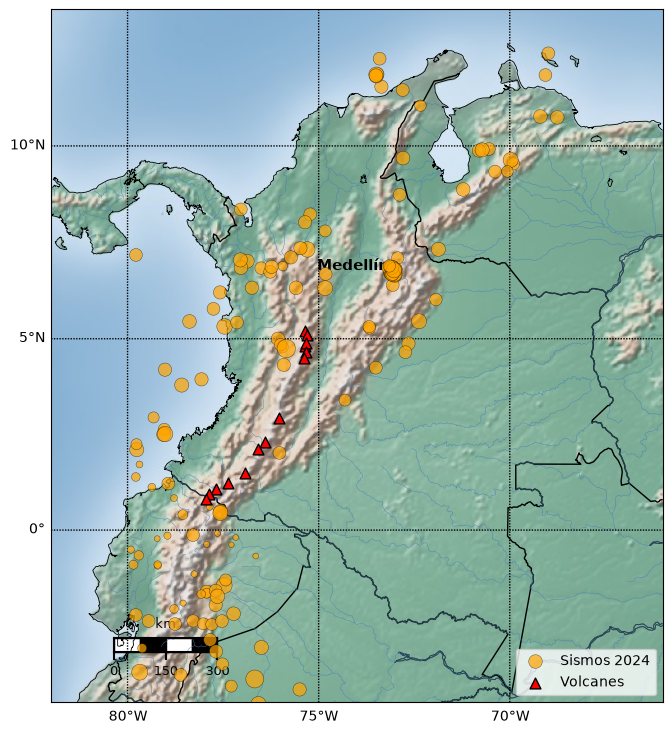

In [59]:
from mpl_toolkits.basemap import Basemap

# 1. Extensión del mapa
x1, x2, y1, y2 = -82., -66., -4.5, 13.5

# 2. Crear el mapa en proyección Mercator
fig, ax = plt.subplots(figsize=(8, 9))
mb = Basemap(resolution='i', projection='merc',
             llcrnrlat=y1, urcrnrlat=y2, llcrnrlon=x1, urcrnrlon=x2,
             lat_ts=(y1 + y2) / 2, ax=ax)

# 3. Capas base
mb.shadedrelief()
mb.drawcoastlines(linewidth=0.6)
mb.drawcountries(linewidth=1)
mb.drawrivers(linewidth=0.3, color='steelblue')

# 4. Grilla y escala
mb.drawparallels(np.arange(-5, 15, 5), labels=[1, 0, 0, 0])
mb.drawmeridians(np.arange(-80, -65, 5), labels=[0, 0, 0, 1])
mb.drawmapscale(-79, -3, -74, 4, 300, barstyle='fancy')

# 5. Sismos: convertir lon/lat a coordenadas del mapa y graficar
xs, ys = mb(sismos.geometry.x.values, sismos.geometry.y.values)
mb.scatter(xs, ys, s=sismos['mag'] ** 3, c='orange', edgecolor='k', linewidth=0.3,
           alpha=0.7, zorder=5, label='Sismos 2024')

# 6. Volcanes
xv, yv = mb(volcanes.geometry.x.values, volcanes.geometry.y.values)
mb.scatter(xv, yv, marker='^', s=60, c='red', edgecolor='k', zorder=6, label='Volcanes')

# 7. Etiqueta de Medellín
xm, ym = mb(-75.58, 6.25)
ax.annotate('Medellín', (xm, ym), xytext=(xm + 6e4, ym + 6e4), fontsize=11, weight='bold')

ax.legend(loc='lower right');

### 6.7 Leaflet

[Leaflet](https://leafletjs.com/) es la librería JavaScript de código abierto más usada para mapas web; folium, ipyleaflet y muchos visores institucionales están construidos sobre ella. Un mapa Leaflet es una **página HTML** con tres partes:

1. cargar `leaflet.css` y `leaflet.js` desde un CDN;
2. un `<div id="map">` que ocupa la página;
3. un `<script>` que crea el mapa (`L.map`), agrega capas (`L.tileLayer`, `L.tileLayer.wms`, `L.geoJSON`) y controles.

Desde Python podemos **escribir la página** insertando los GeoJSON que ya descargamos. El mapa resultante incluye fondos XYZ, el WMTS de la NASA, los WMS del IGAC, los sismos y los volcanes, con leyenda y control de capas. Para profundizar en HTML/CSS/JavaScript vea el notebook `09_Leaflet`.

In [66]:
# 1. Convertir los GeoDataFrames en texto GeoJSON para insertarlos en la página
sismos_leaflet = sismos.copy()
sismos_leaflet['fecha'] = sismos_leaflet['fecha'].dt.strftime('%Y-%m-%d')
sismos_leaflet = sismos_leaflet[['fecha', 'mag', 'place', 'profundidad', 'geometry']]
geo_sismos = sismos_leaflet.to_json()

geo_volcanes = volcanes[['Volcano_Name', 'Last_Eruption_Year', 'geometry']].to_json()

geo_medellin = medellin[['geometry']].to_json()

# 2. Plantilla HTML; los textos __XXX__ se reemplazan en el paso 3
pagina = '''<!DOCTYPE html>
<html>
<head>
  <meta charset="utf-8">
  <title>Geoservicios - Leaflet</title>
  <meta name="viewport" content="width=device-width, initial-scale=1.0">
  <link rel="stylesheet" href="https://cdn.jsdelivr.net/npm/leaflet@1.9.4/dist/leaflet.css"/>
  <script src="https://cdn.jsdelivr.net/npm/leaflet@1.9.4/dist/leaflet.js"></script>
  <style>
    html, body, #map { height: 100%; width: 100%; margin: 0; padding: 0; }
    .leyenda { background: white; padding: 6px 10px; border-radius: 5px; font: 13px sans-serif; line-height: 20px; }
    .leyenda i { display: inline-block; width: 12px; height: 12px; margin-right: 6px; border-radius: 50%; }
  </style>
</head>
<body>
<div id="map"></div>
<script>
  var map = L.map('map', {center: [5.5, -75], zoom: 6});

  // ---- fondos (XYZ / WMTS)
  var gris = L.tileLayer('https://server.arcgisonline.com/ArcGIS/rest/services/Canvas/World_Light_Gray_Base/MapServer/tile/{z}/{y}/{x}',
      {attribution: 'Esri'}).addTo(map);
  var osm = L.tileLayer('https://tile.openstreetmap.org/{z}/{x}/{y}.png',
      {attribution: '&copy; OpenStreetMap contributors'});
  var esri = L.tileLayer('https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
      {attribution: 'Esri'});
  var modis = L.tileLayer('__GIBS__', {attribution: 'NASA GIBS', maxNativeZoom: 9});

  // ---- capa WMS del IGAC
  var srtm = L.tileLayer.wms('__SRTM__', {layers: '0', format: 'image/png', transparent: true, opacity: 0.6, attribution: 'IGAC'});

  // ---- datos vectoriales (GeoJSON)
  function colorProf(p) { return p > 150 ? '#440154' : p > 70 ? '#3b528b' : p > 30 ? '#21918c' : '#fde725'; }

  var sismos = L.geoJSON(__SISMOS__, {
    pointToLayer: function (f, latlng) {
      return L.circleMarker(latlng, {radius: Math.pow(f.properties.mag, 1.6), color: '#333', weight: 0.5,
                                     fillColor: colorProf(f.properties.profundidad), fillOpacity: 0.75});
    },
    onEachFeature: function (f, layer) {
      layer.bindPopup('<b>M ' + f.properties.mag + '</b><br>' + f.properties.place +
                      '<br>' + f.properties.fecha + '<br>Profundidad: ' + f.properties.profundidad.toFixed(0) + ' km');
    }
  }).addTo(map);

  var volcanes = L.geoJSON(__VOLCANES__, {
    pointToLayer: function (f, latlng) {
      return L.marker(latlng, {icon: L.divIcon({html: '<span style="color:red;font-size:16px">&#9650;</span>',
                                                 className: '', iconSize: [16, 16], iconAnchor: [8, 8]})});
    },
    onEachFeature: function (f, layer) {
      layer.bindTooltip(f.properties.Volcano_Name + ' (última erupción: ' + f.properties.Last_Eruption_Year + ')');
    }
  }).addTo(map);

  var medellin = L.geoJSON(__MEDELLIN__, {style: {color: 'black', weight: 2, fill: false}}).addTo(map);

  // ---- controles
  L.control.layers(
    {'Esri gris': gris, 'OpenStreetMap': osm, 'Esri imagen': esri, 'MODIS 2024-01-15 (NASA)': modis},
    {'SRTM 30 m (WMS IGAC)': srtm,
     'Sismos 2024 (USGS)': sismos, 'Volcanes (Smithsonian)': volcanes, 'Medellín (OSM)': medellin},
    {collapsed: false}).addTo(map);
  L.control.scale({imperial: false}).addTo(map);

  var leyenda = L.control({position: 'bottomright'});
  leyenda.onAdd = function () {
    var div = L.DomUtil.create('div', 'leyenda');
    div.innerHTML = '<b>Profundidad (km)</b><br>' +
      '<i style="background:#fde725"></i>0-30<br><i style="background:#21918c"></i>30-70<br>' +
      '<i style="background:#3b528b"></i>70-150<br><i style="background:#440154"></i>&gt;150<br>' +
      '<span style="color:red">&#9650;</span> Volcán';
    return div;
  };
  leyenda.addTo(map);

  // evento: coordenadas al hacer clic
  map.on('click', function (e) {
    L.popup().setLatLng(e.latlng)
      .setContent('Lat: ' + e.latlng.lat.toFixed(4) + '<br>Lon: ' + e.latlng.lng.toFixed(4)).openOn(map);
  });
</script>
</body>
</html>'''

# 3. Reemplazar cada marcador por su valor
pagina = pagina.replace('__GIBS__', gibs_xyz)
pagina = pagina.replace('__SRTM__', url_srtm)
pagina = pagina.replace('__SISMOS__', geo_sismos)
pagina = pagina.replace('__VOLCANES__', geo_volcanes)
pagina = pagina.replace('__MEDELLIN__', geo_medellin)

# 4. Guardar la página
from pathlib import Path
ruta_leaflet = Path('mapa_leaflet.html')
ruta_leaflet.write_text(pagina, encoding='utf-8')
print('Página guardada en', ruta_leaflet)

Página guardada en mapa_leaflet.html


Para verlo dentro del notebook se incrusta en un `iframe` (también se puede abrir el archivo `mapa_leaflet.html` en el navegador o publicarlo en GitHub Pages):

In [67]:
import html
from IPython.display import HTML

# 1. Escapar el HTML para poder ponerlo dentro del atributo srcdoc
pagina_escapada = html.escape(pagina)

# 2. Crear el iframe
iframe = f'<iframe srcdoc="{pagina_escapada}" width="100%" height="650" style="border:none"></iframe>'

HTML(iframe)

C:\Users\edier\AppData\Roaming\Python\Python314\site-packages\IPython\core\display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


#### ipyleaflet

[ipyleaflet](https://ipyleaflet.readthedocs.io/) lleva Leaflet a Jupyter como *widget* interactivo y bidireccional (Python ↔ mapa): se pueden capturar clics, dibujar geometrías y leerlas desde Python. Es la base de [leafmap](https://leafmap.org/).

In [ ]:
!pip install ipyleaflet

In [70]:
from ipyleaflet import Map, WMSLayer, GeoData, LayersControl, basemaps

mapa = Map(center=(6.25, -75.58), zoom=11, basemap=basemaps.Esri.WorldGrayCanvas)
mapa.add(WMSLayer(url=url_srtm, layers='0', format='image/png', transparent=True, name='SRTM IGAC', opacity=0.6))
mapa.add(GeoData(geo_dataframe=equip_pt, name='Equipamientos',
                 point_style={'radius': 4, 'color': 'red', 'fillOpacity': 0.8}))
mapa.add(LayersControl())
mapa

Map(center=[6.25, -75.58], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_o…

In [71]:
from ipyleaflet import Map, WMSLayer, GeoData, LayersControl, Polygon, DrawControl, basemaps
import geopandas as gpd
from shapely.geometry import shape

mapa = Map(center=(6.25, -75.58), zoom=11, basemap=basemaps.Esri.WorldGrayCanvas)
mapa.add(WMSLayer(url=url_srtm, layers='0', format='image/png', transparent=True, name='SRTM IGAC', opacity=0.6))
mapa.add(GeoData(geo_dataframe=equip_pt, name='Equipamientos',
                 point_style={'radius': 4, 'color': 'red', 'fillOpacity': 0.8}))

# 1. Polígono a partir de coordenadas (ojo: ipyleaflet usa (lat, lon))
vertices = [(6.28, -75.60), (6.28, -75.55), (6.22, -75.55), (6.22, -75.60)]
poligono = Polygon(locations=vertices, color='blue', fill_color='blue',
                   fill_opacity=0.2, name='Polígono de ejemplo')
mapa.add(poligono)

# 2. Dibujar polígonos con el mouse
dibujo = DrawControl(polygon={'shapeOptions': {'color': 'green', 'fillOpacity': 0.3}},
                     rectangle={'shapeOptions': {'color': 'orange', 'fillOpacity': 0.3}},
                     polyline={}, circlemarker={})
dibujados = []

def al_dibujar(control, action, geo_json):
    if action == 'created':
        dibujados.append(shape(geo_json['geometry']))

dibujo.on_draw(al_dibujar)
mapa.add(dibujo)

mapa.add(LayersControl())
mapa


Map(center=[6.25, -75.58], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_o…

## Recursos adicionales

* Directorio de servicios del IGAC: [https://mapas.igac.gov.co/server/rest/services](https://mapas.igac.gov.co/server/rest/services)
* Geoportal del Servicio Geológico Colombiano y la [ICDE](https://www.icde.gov.co/) (Infraestructura Colombiana de Datos Espaciales)
* NASA GIBS: [documentación de la API](https://nasa-gibs.github.io/gibs-api-docs/) y [Worldview](https://worldview.earthdata.nasa.gov/)
* USGS: [Earthquake Catalog API](https://earthquake.usgs.gov/fdsnws/event/1/), [The National Map services](https://apps.nationalmap.gov/services/)
* Smithsonian GVP: [webservices](https://volcano.si.edu/database/webservices.cfm)
* STAC: [STAC Index](https://stacindex.org/catalogs), [pystac-client](https://pystac-client.readthedocs.io/)
* Copernicus Data Space: [APIs](https://documentation.dataspace.copernicus.eu/APIs.html)
* OSMnx: [ejemplos](https://github.com/gboeing/osmnx-examples)
* [xyzservices](https://xyzservices.readthedocs.io/): catálogo de proveedores de teselas usado por contextily, folium y Bokeh
* [Leaflet tutorials](https://leafletjs.com/examples.html)